# DodoGo - Exploratory Data Analysis and Demand Diagnostics (NB01)

This notebook supports the demand-analysis block of Chapter 3. It prepares the historical and post-migration order exports, then examines growth, temporal demand, wait time, geography, pricing context and forecasting. The retained outputs are aggregate figures and model diagnostics; raw records and sensitive financial outputs are not shown in the repository version.


## 1. Environment Setup

Imports, plotting configuration and common color constants used across the notebook.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 8), 'font.size': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 120
})

C = {
    'primary': '#1565C0', 'secondary': '#FF5722', 'success': '#4CAF50',
    'warning': '#FF9800', 'danger': '#E53935', 'purple': '#9C27B0',
    'old': '#2196F3', 'new': '#FF5722', 'gray': '#9E9E9E'
}
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Cleaning and Platform Harmonization

The old and new platform exports use different encodings, date formats and column names. This section converts both exports into a comparable analytical structure: creation time, completion flag, driver assignment flag, trip distance, price and coarse time features. The purpose is not to rebuild the full operational database, but to create a consistent order-level table for aggregate analysis.


In [ ]:
df_new = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df_old = pd.read_csv("../data/raw/orders_old_platform.csv",
                       sep=";", encoding="latin1", low_memory=False, on_bad_lines='skip')

# New platform cleaning
df_new['created'] = pd.to_datetime(df_new['Дата создания'], format="%d.%m.%Y %H:%M", errors='coerce')
for col in ['Стоимость', 'Суммарное расстояние (км)', 'Наличные', 'Комиссия с исполнителя']:
    df_new[col] = df_new[col].astype(str).str.replace(',', '.').astype(float)

df_new.rename(columns={
    'Стоимость': 'price', 'Суммарное расстояние (км)': 'distance_km',
    'Текущий статус': 'status', 'Тариф': 'tariff', 'Способ заказа': 'order_source',
    'Исполнитель': 'driver', 'Телефон клиента': 'client_phone',
    'Адрес подачи': 'pickup_address', 'Адрес назначения': 'dropoff_address',
    'Район адреса подачи': 'pickup_district', 'Наличные': 'cash_paid',
    'Комиссия с исполнителя': 'driver_commission'
}, inplace=True)

df_new['is_completed'] = df_new['status'].str.contains('Выполнен', na=False)
df_new['has_driver'] = df_new['driver'].notna() & (df_new['driver'].str.strip() != '')
df_new['hour'] = df_new['created'].dt.hour
df_new['day_of_week'] = df_new['created'].dt.dayofweek
df_new['date'] = df_new['created'].dt.date
df_new['month_num'] = df_new['created'].dt.month

# Old platform cleaning
df_old['created'] = pd.to_datetime(df_old['Created at'], errors='coerce')
df_old['Price'] = pd.to_numeric(df_old['Price'], errors='coerce')
df_old['Trip mileage'] = pd.to_numeric(df_old['Trip mileage'], errors='coerce')
df_old.rename(columns={'Price': 'price', 'Trip mileage': 'distance_km',
    'Status': 'status', 'Service class': 'tariff',
    'Passenger phone number': 'client_phone', 'From': 'pickup_address', 'To': 'dropoff_address'
}, inplace=True)
df_old['is_completed'] = df_old['status'] == 'Completed'
df_old['hour'] = df_old['created'].dt.hour
df_old['day_of_week'] = df_old['created'].dt.dayofweek
df_old['date'] = df_old['created'].dt.date

print(f"New platform: {len(df_new):,} orders ({df_new['created'].min().date()} to {df_new['created'].max().date()})")
print(f"  Completed: {df_new['is_completed'].sum():,} ({df_new['is_completed'].mean()*100:.1f}%)")
print(f"\nOld platform: {len(df_old):,} orders ({df_old['created'].min().date()} to {df_old['created'].max().date()})")
print(f"  Completed: {df_old['is_completed'].sum():,} ({df_old['is_completed'].mean()*100:.1f}%)")
print(f"\n{'='*50}")
print(f"TOTAL: {len(df_new)+len(df_old):,} orders, {df_new['is_completed'].sum()+df_old['is_completed'].sum():,} completed")


New platform: 116,958 orders (2025-10-01 to 2026-04-07)
  Completed: 63,368 (54.2%)

Old platform: 151,225 orders (2023-11-13 to 2025-10-03)
  Completed: 62,196 (41.1%)

TOTAL: 268,183 orders, 125,564 completed


## 3. Platform Growth and Conversion Dynamics

This section measures completed-order growth and conversion before and after the platform migration. It is used in the thesis to describe the scale-up phase and to check whether the October 2025 migration disrupted demand or completion behavior.


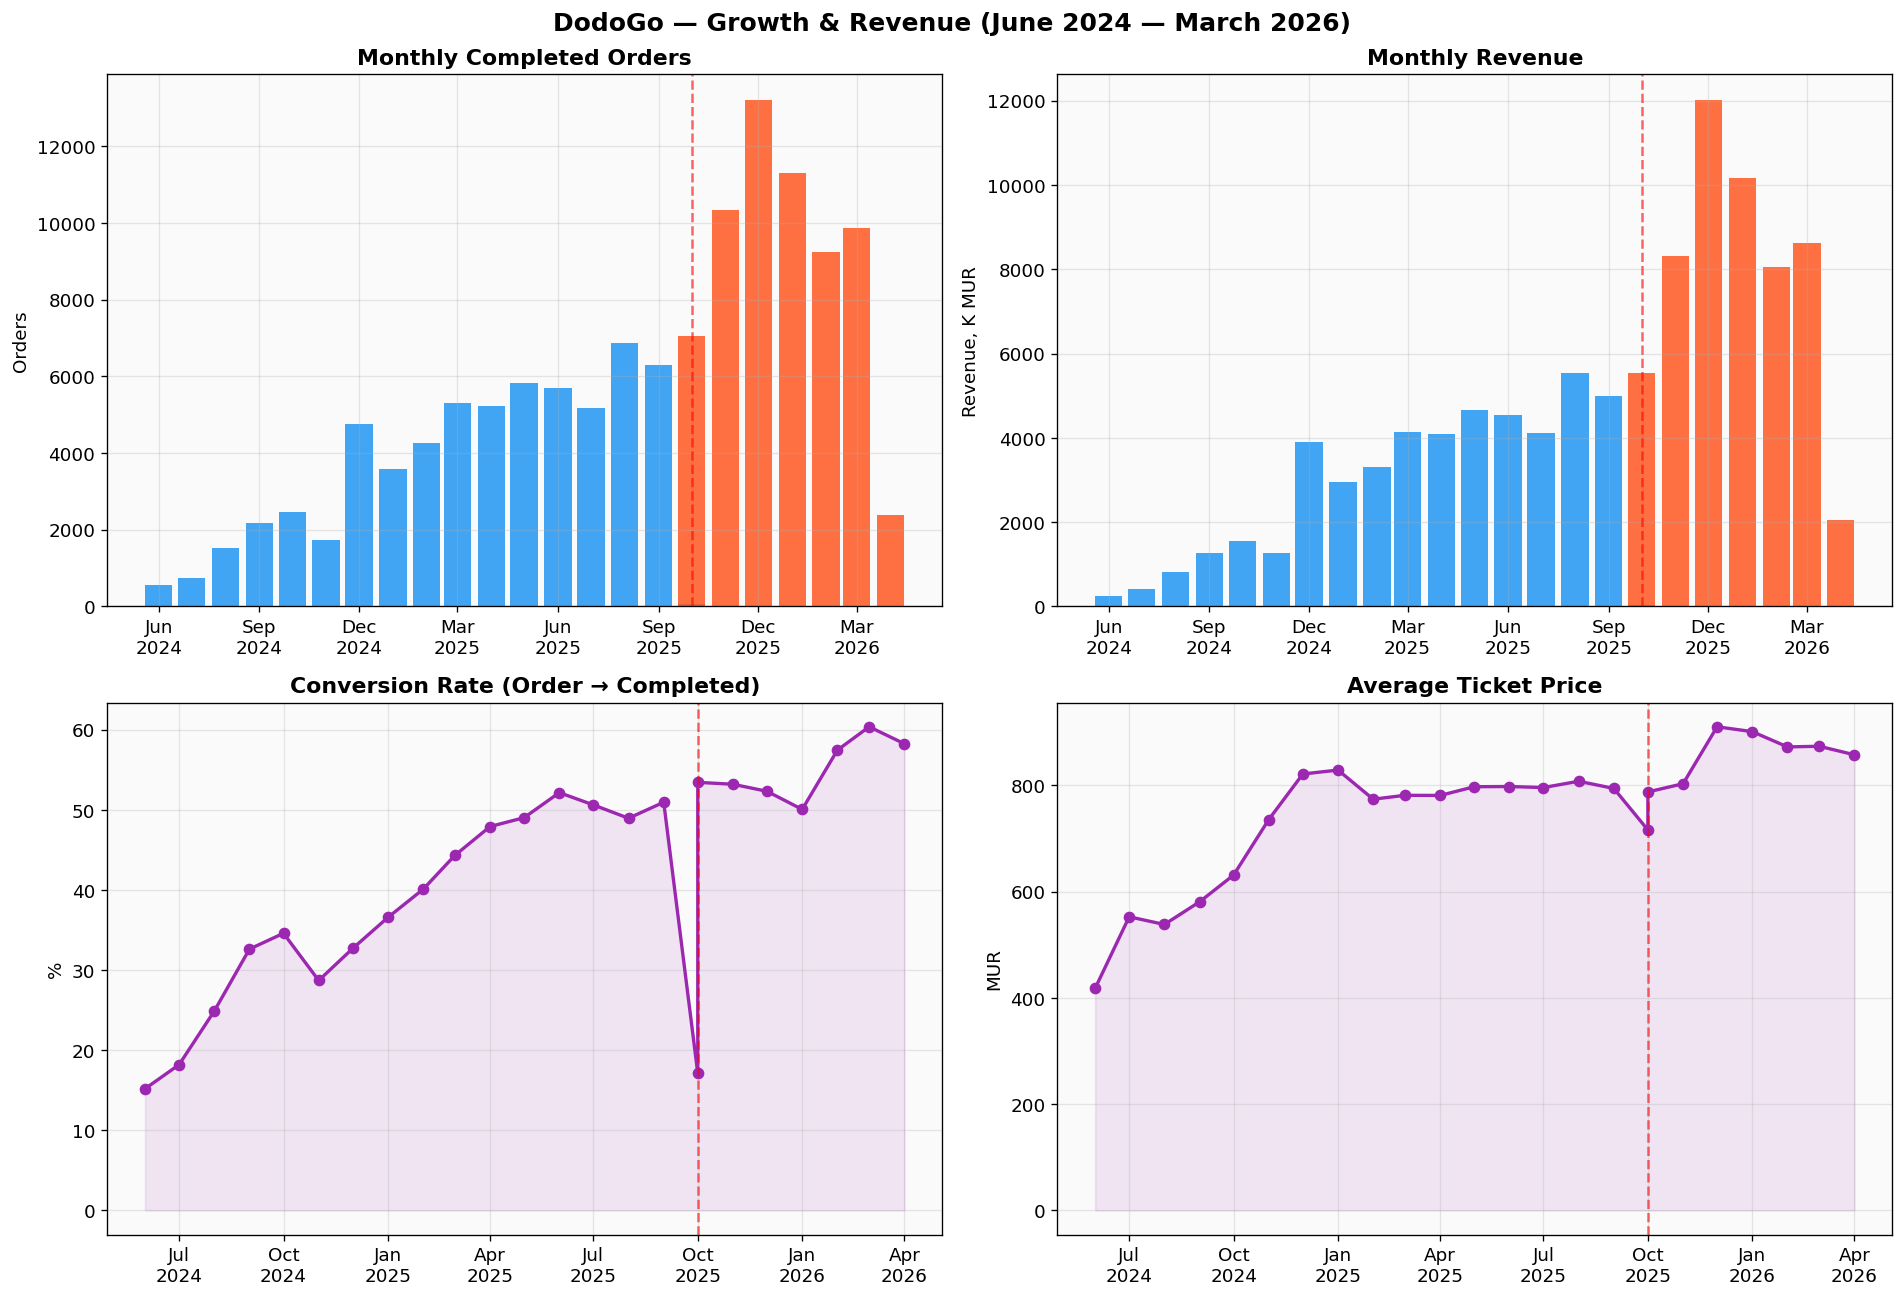


GROWTH SUMMARY
First full month (Jun 2024):  565 completed orders
Peak month (Dec 2025):        13209 completed orders
Growth factor:                23x over 18 months
Avg conversion (old):         36.7%
Avg conversion (new):         55.0%
Conversion improvement:       +18.3 percentage points


In [ ]:
def monthly_stats(df, label):
    comp = df[df['is_completed']].copy()
    m = comp.groupby(comp['created'].dt.to_period('M')).agg(
        completed=('is_completed', 'count'))
    total = df.groupby(df['created'].dt.to_period('M')).size().rename('total')
    m = m.join(total)
    m['conversion'] = m['completed'] / m['total'] * 100
    m['platform'] = label
    return m

monthly = pd.concat([monthly_stats(df_old, 'Old'), monthly_stats(df_new, 'New')])
monthly.index = monthly.index.to_timestamp()
monthly = monthly[monthly.index >= '2024-06-01'].sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DodoGo - Growth and Conversion', fontsize=15, fontweight='bold')

colors = [C['old'] if p == 'Old' else C['new'] for p in monthly['platform']]
ax = axes[0]
ax.bar(monthly.index, monthly['completed'], width=25, color=colors, alpha=0.85)
ax.axvline(pd.Timestamp('2025-10-01'), color='red', linestyle='--', alpha=0.6)
ax.set_title('Monthly Completed Orders', fontweight='bold')
ax.set_ylabel('Orders')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b
%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax = axes[1]
ax.plot(monthly.index, monthly['conversion'], marker='o', color=C['purple'], linewidth=2)
ax.fill_between(monthly.index, monthly['conversion'], alpha=0.1, color=C['purple'])
ax.axvline(pd.Timestamp('2025-10-01'), color='red', linestyle='--', alpha=0.6)
ax.set_title('Conversion Rate', fontweight='bold')
ax.set_ylabel('% completed')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b
%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.tight_layout(); plt.show()

first_month = monthly.iloc[0]['completed']
peak_month = monthly['completed'].max()
conv_old = monthly[monthly['platform']=='Old']['conversion'].mean()
conv_new = monthly[monthly['platform']=='New']['conversion'].mean()

print(f"
{'='*60}")
print('GROWTH SUMMARY')
print(f"{'='*60}")
print(f"First full month (Jun 2024):  {first_month:.0f} completed orders")
print(f"Peak month (Dec 2025):        {peak_month:.0f} completed orders")
print(f"Growth factor:                {peak_month/first_month:.0f}x over 18 months")
print(f"Avg conversion (old):         {conv_old:.1f}%")
print(f"Avg conversion (new):         {conv_new:.1f}%")
print(f"Conversion improvement:       +{conv_new - conv_old:.1f} percentage points")


### Result Interpretation

The platform shows rapid demand growth across the observation period. Conversion improves after the migration, which suggests that the new platform did not create a visible operational break in the aggregate demand series. The public notebook keeps order and conversion outputs, while exact revenue visuals are omitted for confidentiality.


## 4. Temporal Demand Patterns

Hourly, weekday and daily patterns are examined to understand when driver supply is most needed. These outputs support operational planning and provide context for later cancellation and positioning models.


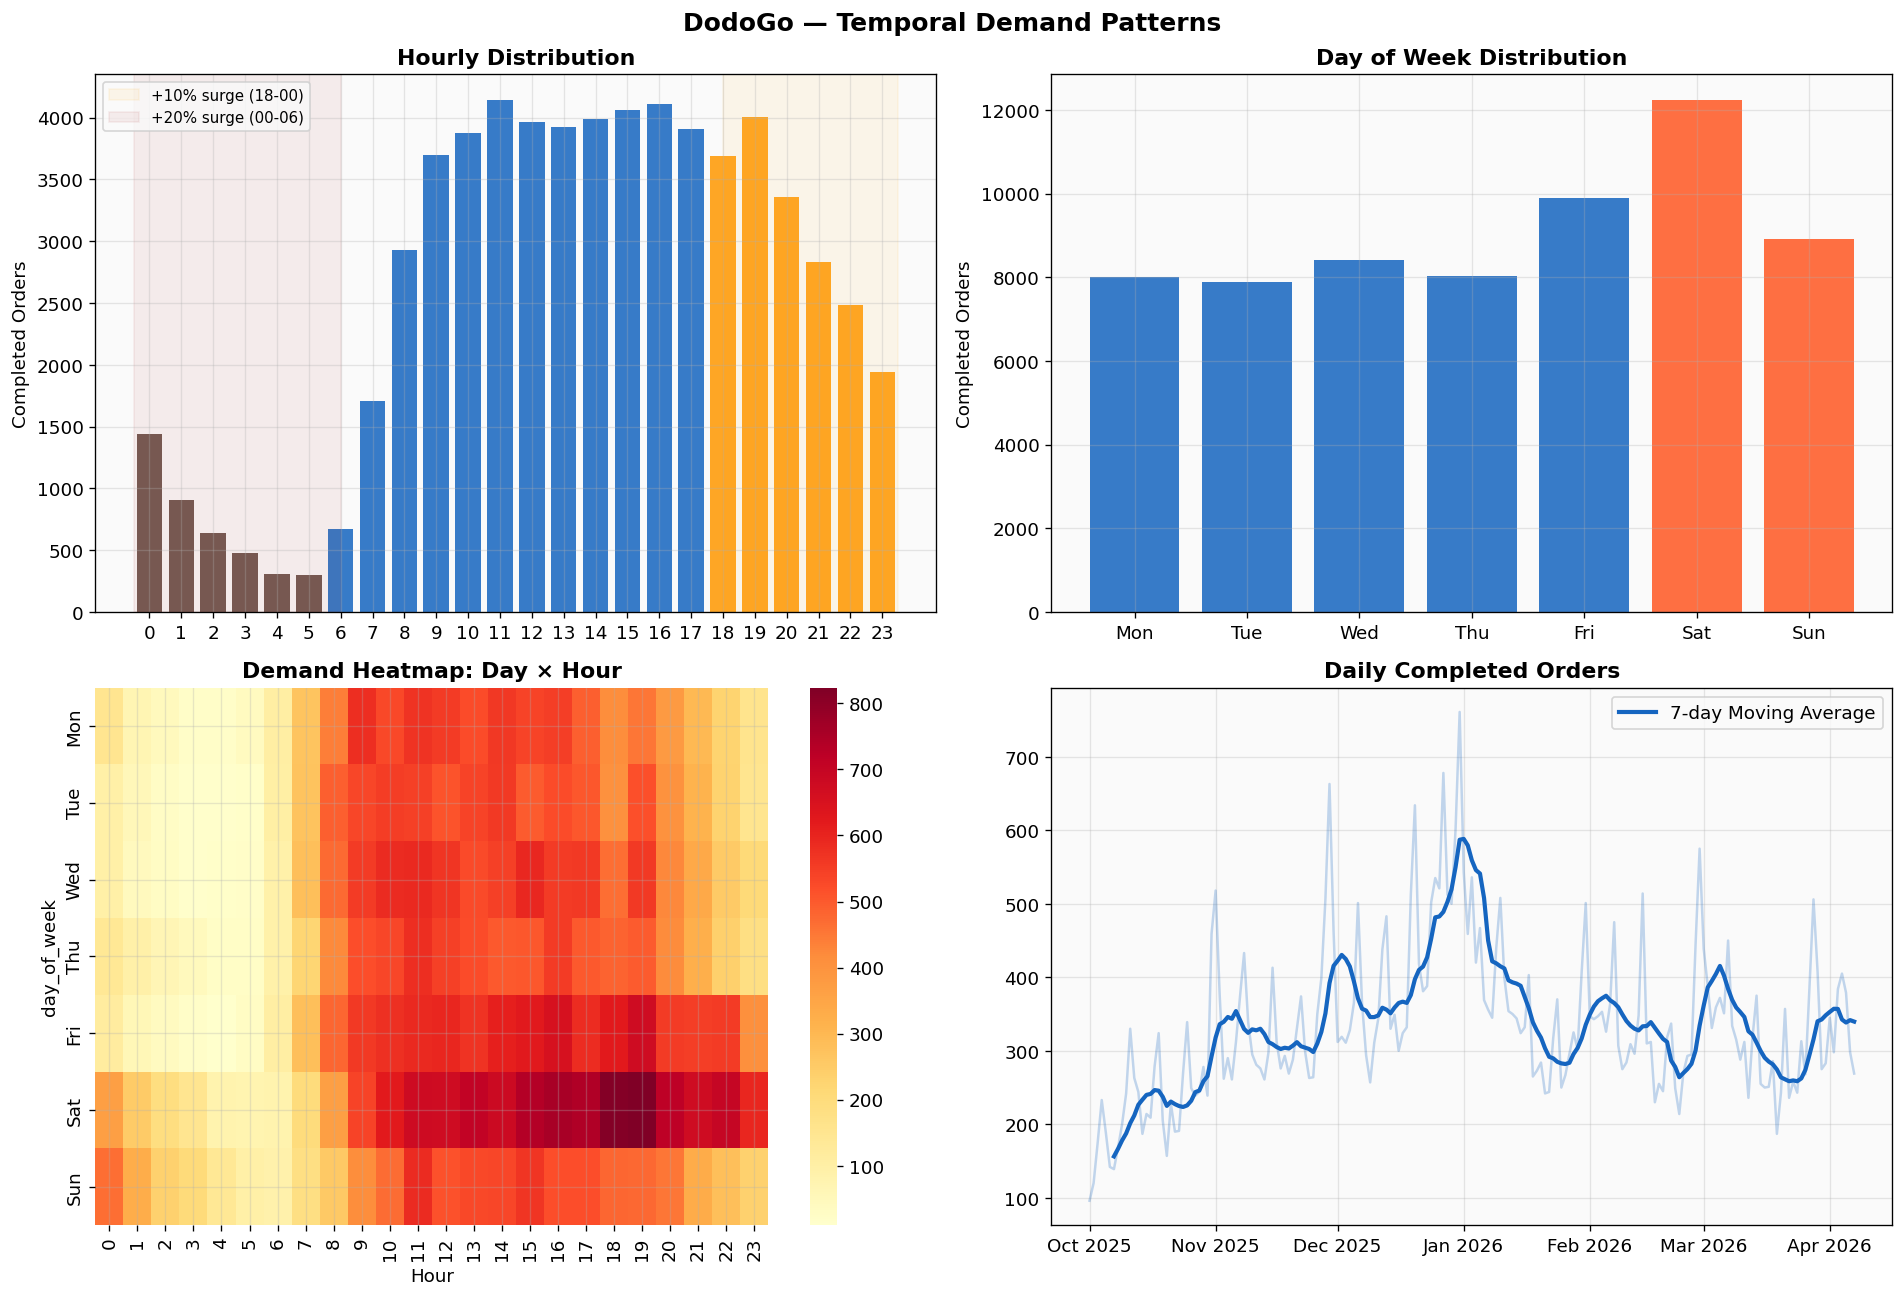


TEMPORAL INSIGHTS
Peak hour:         11:00 (4,143 orders)
Saturday orders:   12,235 (+45% vs weekday avg)
Night orders:      4,066 (6.4% of total, 00-06h)
Avg daily orders:  335
Max daily orders:  761 on 2025-12-31


In [ ]:
comp = df_new[df_new['is_completed']].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DodoGo — Temporal Demand Patterns', fontsize=15, fontweight='bold')

ax = axes[0, 0]
hours = comp['hour'].value_counts().sort_index()
clrs = [C['primary'] if 6<=h<18 else C['warning'] if 18<=h<24 else '#5D4037' for h in range(24)]
ax.bar(hours.index, hours.values, color=clrs, alpha=0.85)
ax.axvspan(18, 23.5, alpha=0.07, color='orange', label='+10% surge (18-00)')
ax.axvspan(-0.5, 6, alpha=0.07, color='brown', label='+20% surge (00-06)')
ax.set_title('Hourly Distribution', fontweight='bold'); ax.set_xticks(range(0,24)); ax.legend(fontsize=9)
ax.set_ylabel('Completed Orders')

ax = axes[0, 1]
dow = comp['day_of_week'].value_counts().sort_index()
ax.bar(range(7), dow.values, color=[C['primary']]*5+[C['secondary']]*2, alpha=0.85)
ax.set_xticks(range(7)); ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Day of Week Distribution', fontweight='bold'); ax.set_ylabel('Completed Orders')

ax = axes[1, 0]
hm = comp.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
sns.heatmap(hm, ax=ax, cmap='YlOrRd', yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_title('Demand Heatmap: Day × Hour', fontweight='bold'); ax.set_xlabel('Hour')

ax = axes[1, 1]
daily = comp.set_index('created').resample('D').size()
ax.plot(daily.index, daily.values, alpha=0.25, color=C['primary'])
ax.plot(daily.rolling(7).mean().index, daily.rolling(7).mean().values, 
        color=C['primary'], linewidth=2.5, label='7-day Moving Average')
ax.set_title('Daily Completed Orders', fontweight='bold'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

peak_hour = hours.idxmax()
sat_avg = dow[5]; wd_avg = dow[0:5].mean()
night = hours[0:6].sum(); total_h = hours.sum()
print(f"\n{'='*60}")
print(f"TEMPORAL INSIGHTS")
print(f"{'='*60}")
print(f"Peak hour:         {peak_hour}:00 ({hours.max():,} orders)")
print(f"Saturday orders:   {sat_avg:,} ({sat_avg/wd_avg*100-100:+.0f}% vs weekday avg)")
print(f"Night orders:      {night:,} ({night/total_h*100:.1f}% of total, 00-06h)")
print(f"Avg daily orders:  {daily.mean():.0f}")
print(f"Max daily orders:  {daily.max()} on {daily.idxmax().date()}")


### Result Interpretation

Demand is not limited to morning and evening commute peaks. Activity remains high through the daytime and strengthens on Saturdays, which is consistent with a mix of local mobility and tourism-driven trips. This pattern matters because driver allocation should follow both commuter and leisure demand.


## 4b. Wait-Time Dynamics

Wait time is one of the most visible passenger-experience metrics. Because the new platform export does not contain complete arrival timestamps, this section uses the old platform where the necessary fields are available. The analysis is treated as an operational diagnostic rather than a complete post-migration measurement.


Matched orders: 93,482  |  Completed: 56,775
Median wait: 5.98 min | P90: 15.27 | P95: 19.45
Median accept: 0.67 min (< 1 min — dispatch is fast)
Median drive-to-pickup: 5.20 min (drive time dominates wait)

Top districts by wait:
                       median   mean     n
district                                  
Moka                     6.65   7.88  4124
Riviere du Rempart       4.40   6.36  3051
Port Louis               6.60   8.19  1803
Vacoas-Phoenix           6.37   7.62  1368
Quatre Bornes            5.49   6.89  1306
Black River              8.62  10.39  1183
Pamplemousses            7.98   9.05  1168
Beau Bassin-Rose Hill    5.10   7.26   821
Curepipe                 4.80   6.71   429
Grand Port               5.28   8.10   355

Completion by wait bucket:
            n  completion  cancel_rate
bucket                                
0-3     18221       0.698        0.302
3-5     15968       0.670        0.330
5-7     14304       0.650        0.350
7-10    15768       0.591     

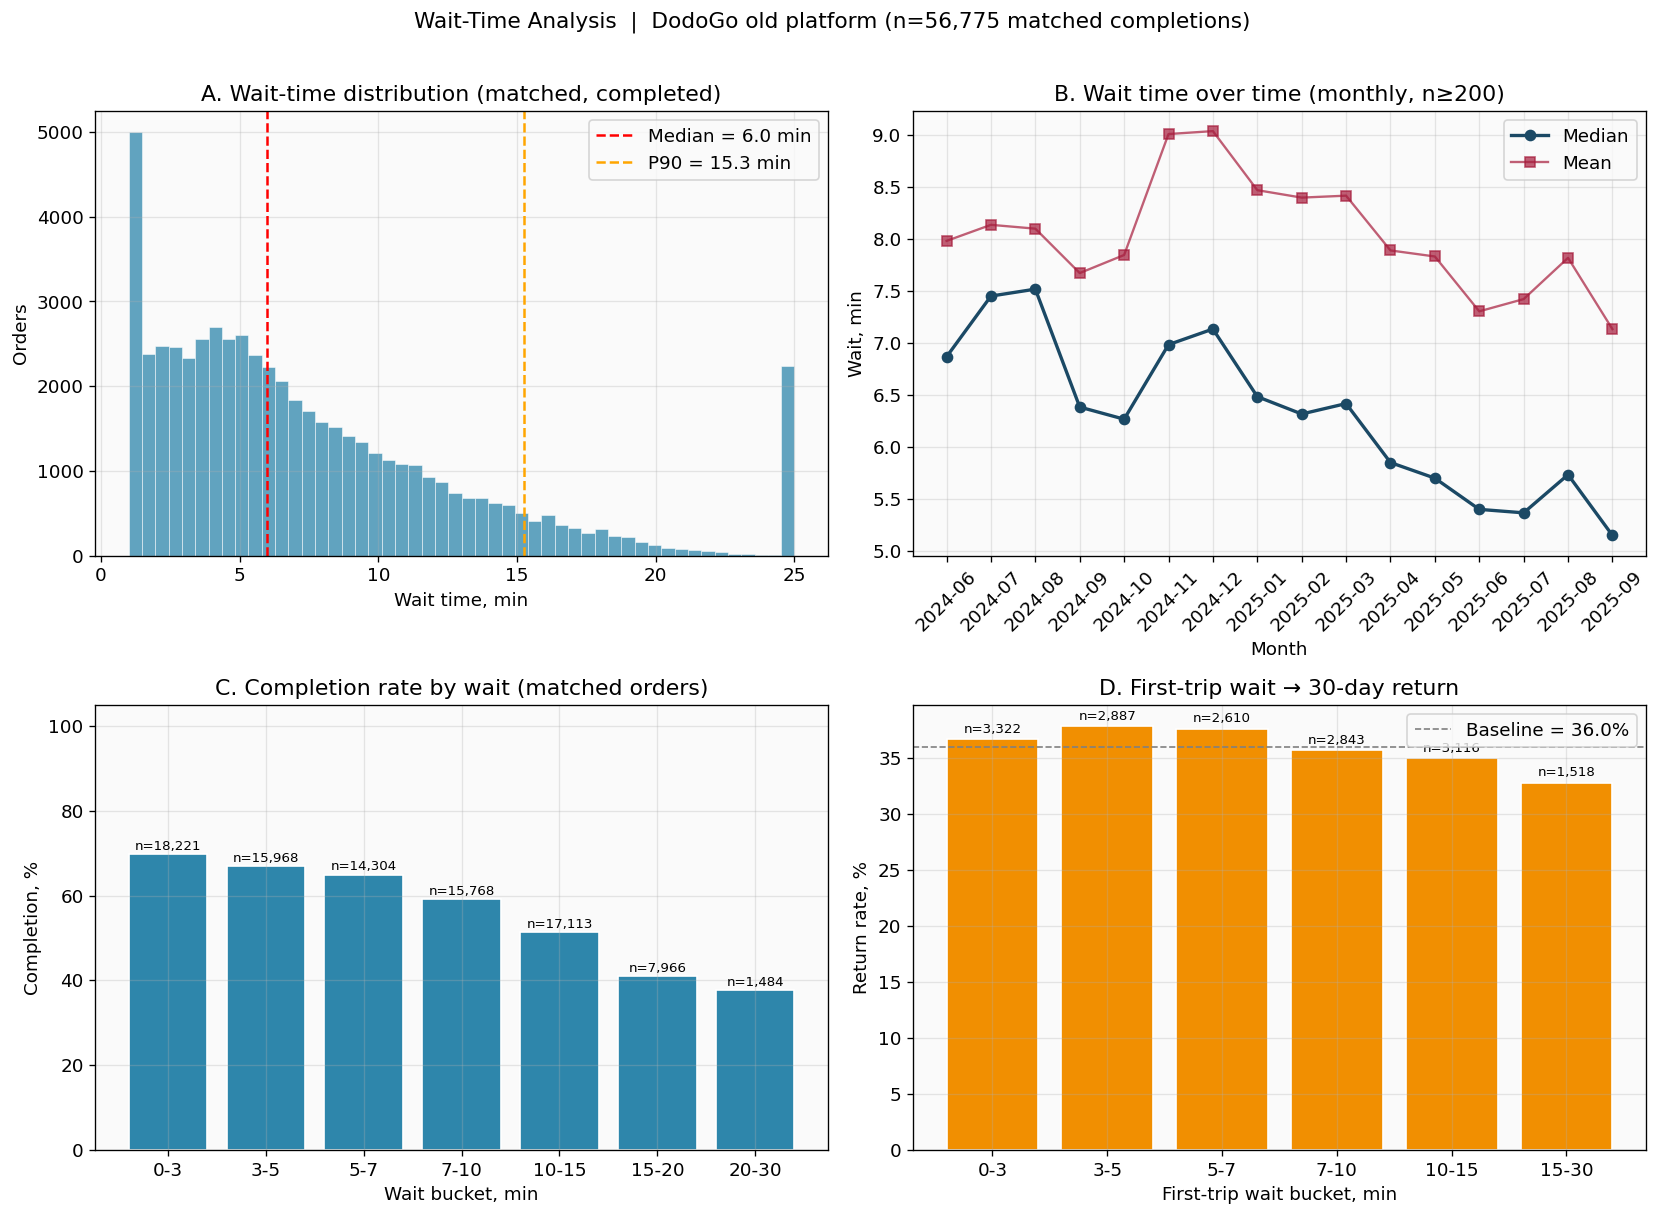

In [ ]:
# Uses OLD platform only (new platform doesn't log arrival timestamps).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc

usecols = ["Trip ID","Status","From","Created at","Pickup time",
           "Trip accepted at","Passenger phone number"]
wt = pd.read_csv("../data/raw/orders_old_platform.csv",
                 sep=";", encoding="latin-1",
                 usecols=usecols, on_bad_lines="skip", low_memory=False)

for c in ["Created at","Pickup time","Trip accepted at"]:
    wt[c] = pd.to_datetime(wt[c], errors="coerce")

wt["wait_min"]   = (wt["Pickup time"] - wt["Created at"]).dt.total_seconds()/60
wt["accept_min"] = (wt["Trip accepted at"] - wt["Created at"]).dt.total_seconds()/60
wt["arrive_min"] = (wt["Pickup time"] - wt["Trip accepted at"]).dt.total_seconds()/60

# Matched immediate orders only - the only regime where wait_min is real
matched = wt[wt["Trip accepted at"].notna() &
             wt["wait_min"].between(0.5, 60) &
             wt["accept_min"].between(0, 30)].copy()
comp = matched[matched["Status"] == "Completed"].copy()
print(f"Matched orders: {len(matched):,}  |  Completed: {len(comp):,}")

med = comp["wait_min"].median()
p90 = comp["wait_min"].quantile(0.9)
print(f"Median wait: {med:.2f} min | P90: {p90:.2f} | P95: {comp['wait_min'].quantile(0.95):.2f}")
print(f"Median accept: {comp['accept_min'].median():.2f} min (< 1 min — dispatch is fast)")
print(f"Median drive-to-pickup: {comp['arrive_min'].median():.2f} min (drive time dominates wait)")

comp["hour"] = comp["Created at"].dt.hour
hourly = comp.groupby("hour")["wait_min"].median()

comp["month"] = comp["Created at"].dt.to_period("M")
monthly = comp.groupby("month").agg(median=("wait_min","median"),
                                     mean=("wait_min","mean"),
                                     n=("wait_min","size"))
monthly = monthly[monthly["n"] >= 200]

DISTRICT_MAP = {
    "port louis":"Port Louis","pointe aux sables":"Port Louis","caudan":"Port Louis",
    "black river":"Black River","tamarin":"Black River","albion":"Black River",
    "bambous":"Black River","flic en flac":"Black River","cascavelle":"Black River",
    "grand baie":"Riviere du Rempart","grand bay":"Riviere du Rempart",
    "cap malheureux":"Riviere du Rempart","goodlands":"Riviere du Rempart",
    "mon choisy":"Pamplemousses","trou aux biches":"Pamplemousses",
    "triolet":"Pamplemousses","pamplemousses":"Pamplemousses",
    "beau bassin-rose hill":"Beau Bassin-Rose Hill","beau bassin":"Beau Bassin-Rose Hill",
    "rose hill":"Beau Bassin-Rose Hill","quatre bornes":"Quatre Bornes",
    "trianon":"Quatre Bornes","vacoas-phoenix":"Vacoas-Phoenix","vacoas":"Vacoas-Phoenix",
    "phoenix":"Vacoas-Phoenix","curepipe":"Curepipe","moka":"Moka",
    "saint pierre":"Moka","bagatelle":"Moka","tribeca":"Moka","ebene":"Moka",
    "airport":"Grand Port","mahebourg":"Grand Port","plaine magnien":"Grand Port",
    "plaisance":"Grand Port","souillac":"Savanne","savanne":"Savanne"}
def to_district(s):
    if pd.isna(s): return None
    s = str(s).lower()
    for k,v in DISTRICT_MAP.items():
        if k in s: return v
    return None

comp["district"] = comp["From"].apply(to_district)
district = (comp.dropna(subset=["district"]).groupby("district")
            .agg(median=("wait_min","median"),
                 mean=("wait_min","mean"),
                 n=("wait_min","size"))
            .sort_values("n", ascending=False).head(10))
print("\nTop districts by wait:")
print(district.round(2))

matched["bucket"] = pd.cut(matched["wait_min"],
                           [0,3,5,7,10,15,20,30],
                           labels=["0-3","3-5","5-7","7-10","10-15","15-20","20-30"])
bucket = (matched.groupby("bucket", observed=True)
          .agg(n=("Status","size"),
               completion=("Status", lambda s: (s=="Completed").mean())))
bucket["cancel_rate"] = 1 - bucket["completion"]
print("\nCompletion by wait bucket:")
print(bucket.round(3))

c = comp.sort_values(["Passenger phone number","Created at"]).reset_index(drop=True)
c["rank"] = c.groupby("Passenger phone number").cumcount()
first = (c[c["rank"]==0][["Passenger phone number","Created at","wait_min"]]
         .rename(columns={"Created at":"first_ts","wait_min":"first_wait"}))
second = (c[c["rank"]==1][["Passenger phone number","Created at"]]
          .rename(columns={"Created at":"second_ts"}))
first = first.merge(second, on="Passenger phone number", how="left")
first["days_to_second"] = (first["second_ts"] - first["first_ts"]).dt.days
first["returned_30d"] = (first["days_to_second"] <= 30) & first["days_to_second"].notna()
first["b"] = pd.cut(first["first_wait"],
                    [0,3,5,7,10,15,30],
                    labels=["0-3","3-5","5-7","7-10","10-15","15-30"])
ret = first.groupby("b", observed=True).agg(
    n=("returned_30d","size"),
    rate=("returned_30d","mean"))
print(f"\nFirst-trip wait → 30-day return (baseline {first['returned_30d'].mean():.1%}):")
print(ret.round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.hist(comp["wait_min"].clip(upper=25), bins=50,
        color="#2E86AB", alpha=0.75, edgecolor="white", linewidth=0.4)
ax.axvline(med, color="red", linestyle="--", linewidth=1.5,
           label=f"Median = {med:.1f} min")
ax.axvline(p90, color="orange", linestyle="--", linewidth=1.5,
           label=f"P90 = {p90:.1f} min")
ax.set_title("A. Wait-time distribution (matched, completed)")
ax.set_xlabel("Wait time, min"); ax.set_ylabel("Orders"); ax.legend()

ax = axes[0,1]
x = monthly.index.astype(str)
ax.plot(x, monthly["median"], marker="o", color="#1B4965", linewidth=2, label="Median")
ax.plot(x, monthly["mean"],   marker="s", color="#A61C3C", linewidth=1.4,
        alpha=0.7, label="Mean")
ax.set_title("B. Wait time over time (monthly, n≥200)")
ax.set_xlabel("Month"); ax.set_ylabel("Wait, min")
ax.tick_params(axis="x", rotation=45); ax.legend()

ax = axes[1,0]
bars = ax.bar(bucket.index.astype(str), bucket["completion"]*100,
              color="#2E86AB", edgecolor="white")
for bar, n in zip(bars, bucket["n"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"n={n:,}",
            ha="center", fontsize=8)
ax.set_title("C. Completion rate by wait (matched orders)")
ax.set_xlabel("Wait bucket, min"); ax.set_ylabel("Completion, %"); ax.set_ylim(0,105)

ax = axes[1,1]
baseline = first["returned_30d"].mean()*100
bars = ax.bar(ret.index.astype(str), ret["rate"]*100,
              color="#F18F01", edgecolor="white")
for bar, n in zip(bars, ret["n"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6, f"n={n:,}",
            ha="center", fontsize=8)
ax.axhline(baseline, color="grey", linestyle="--", linewidth=1,
           label=f"Baseline = {baseline:.1f}%")
ax.set_title("D. First-trip wait → 30-day return")
ax.set_xlabel("First-trip wait bucket, min"); ax.set_ylabel("Return rate, %"); ax.legend()

plt.suptitle(f"Wait-Time Analysis  |  DodoGo old platform "
             f"(n={len(comp):,} matched completions)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig_wait_time_analysis.png", bbox_inches="tight", dpi=140)
plt.show()

gc.collect()


### Result Interpretation

Most measured wait time comes from the drive-to-pickup interval rather than from dispatch itself. Longer waits are associated with weaker completion, which makes wait time a useful service-quality signal even though the metric is only available for the old platform. The limitation is carried into the thesis as a data-quality issue.


## 5. Geographic Demand and Fare Context

This section summarizes pickup geography, trip distance and fare distribution. The goal is to distinguish demand concentration from service difficulty: high fares often reflect longer trips and geography, not simply willingness to pay.


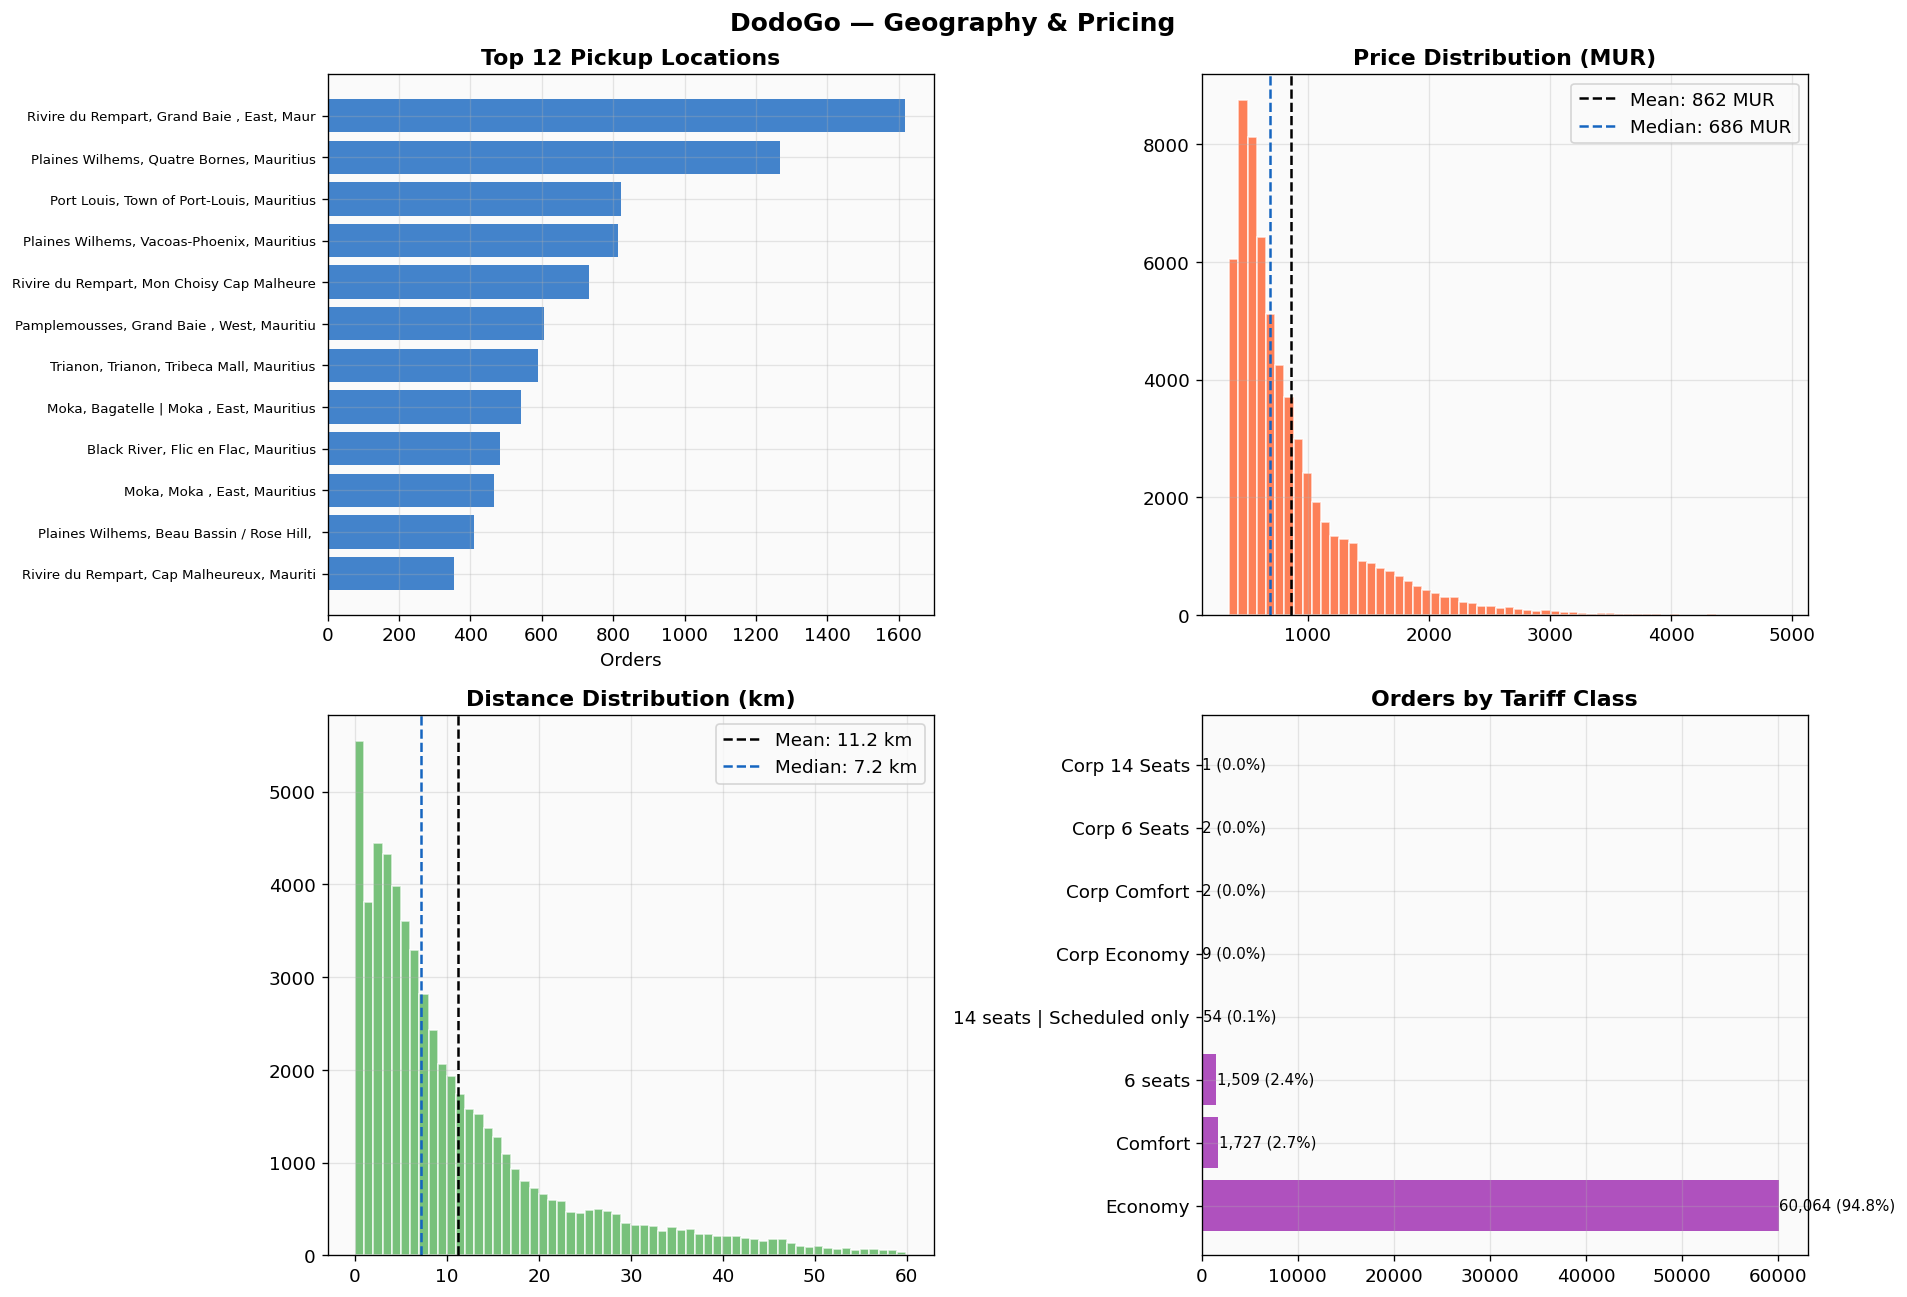

GEOGRAPHY AND FARE STRUCTURE SUMMARY
Completed trips show a short-to-medium ride profile and strong concentration in the Economy tariff.
Grand Baie, Port Louis, Quatre Bornes and other dense urban/tourist areas form the main operational base.
Exact fare values are omitted from the public output; the retained chart supports relative distributional interpretation.


In [ ]:
comp = df_new[df_new['is_completed']].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('DodoGo — Geography & Pricing', fontsize=15, fontweight='bold')

ax = axes[0, 0]
top = comp['pickup_address'].value_counts().head(12)
ax.barh(range(len(top)), top.values, color=C['primary'], alpha=0.8)
ax.set_yticks(range(len(top))); ax.set_yticklabels([str(a)[:42] for a in top.index], fontsize=8)
ax.set_title('Top 12 Pickup Locations', fontweight='bold'); ax.invert_yaxis(); ax.set_xlabel('Orders')

ax = axes[0, 1]
p = comp.loc[(comp['price']>0)&(comp['price']<5000), 'price']
ax.hist(p, bins=60, color=C['secondary'], alpha=0.75, edgecolor='white')
ax.axvline(p.mean(), color='k', ls='--', lw=1.5, label=f'Mean: {p.mean():.0f} MUR')
ax.axvline(p.median(), color=C['primary'], ls='--', lw=1.5, label=f'Median: {p.median():.0f} MUR')
ax.set_title('Price Distribution (MUR)', fontweight='bold'); ax.legend()

ax = axes[1, 0]
d = comp.loc[(comp['distance_km']>0)&(comp['distance_km']<60), 'distance_km']
ax.hist(d, bins=60, color=C['success'], alpha=0.75, edgecolor='white')
ax.axvline(d.mean(), color='k', ls='--', lw=1.5, label=f'Mean: {d.mean():.1f} km')
ax.axvline(d.median(), color=C['primary'], ls='--', lw=1.5, label=f'Median: {d.median():.1f} km')
ax.set_title('Distance Distribution (km)', fontweight='bold'); ax.legend()

ax = axes[1, 1]
t = comp['tariff'].value_counts()
ax.barh(t.index, t.values, color=C['purple'], alpha=0.8)
ax.set_title('Orders by Tariff Class', fontweight='bold')
for i, (idx, val) in enumerate(t.items()):
    ax.text(val+50, i, f'{val:,} ({val/len(comp)*100:.1f}%)', va='center', fontsize=9)

plt.tight_layout(); plt.show()

print(f"\nMean price: {p.mean():.0f} MUR (~${p.mean()/45:.2f} USD)")
print(f"Median price: {p.median():.0f} MUR")
print(f"Mean distance: {d.mean():.1f} km, Median: {d.median():.1f} km")
print(f"Economy share: {(comp['tariff']=='Economy').sum()/len(comp)*100:.1f}%")


### Result Interpretation

Demand is concentrated in tourist and urban zones. Fare and distance distributions confirm that different areas serve different trip purposes, so later recommendations should not treat the island as one uniform market. Geography becomes a central input for driver positioning and tourist strategy.


## 5b. Price-Acceptance and Area-Level Fare Diagnostics

Price is observed mainly for completed trips, so the notebook cannot estimate classical price elasticity from accepted and rejected offers. Instead, it studies completed fares, surcharge windows, area-level completion and first-trip fare bands. This framing is the basis for Section 3.2.4 of the thesis.


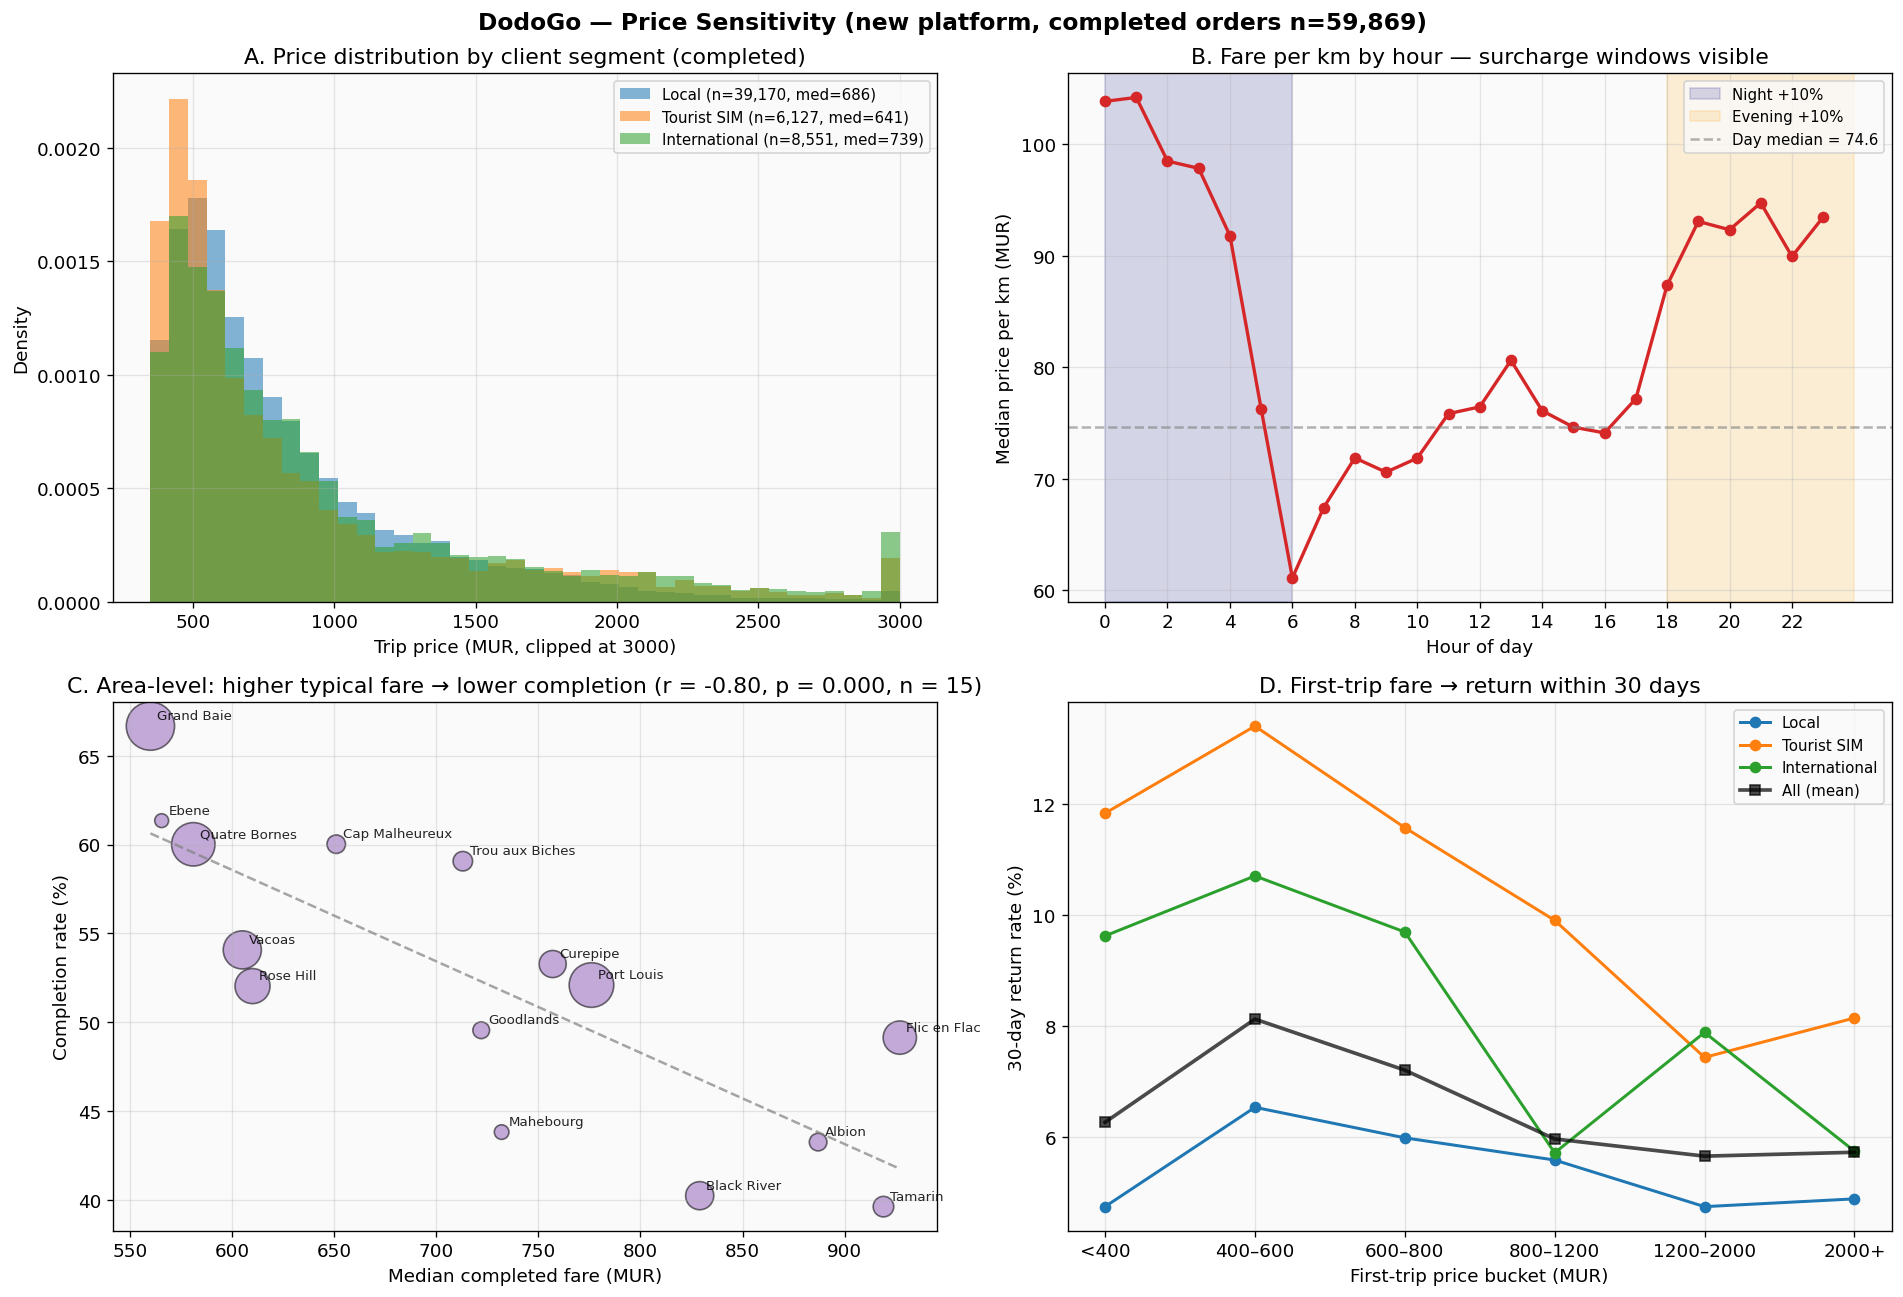

PRICE ACCEPTANCE SUMMARY
Completion differs materially by user segment, tariff window and pickup area.
The area-level association between fare level and completion is strongly negative (r=-0.799, p=0.0004), which is interpreted as a diagnostic signal of supply friction and trip-distance effects rather than causal price elasticity.
First-trip return is strongest in the lower-middle fare bucket; exact fare tables are omitted from the public output.


In [ ]:
# Price only populated on completion; cancelled orders carry 0 price.
# This section characterises price acceptance along 4 axes: segment, surcharge window, area, first-trip retention.

import pandas as pd, numpy as np, matplotlib.pyplot as plt, gc
from scipy.stats import pearsonr

df_ps = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
for c in ["Стоимость", "Суммарное расстояние (км)"]:
    df_ps[c] = df_ps[c].astype(str).str.replace(",", ".").replace("nan", np.nan).astype(float)

df_ps["is_completed"] = df_ps["Текущий статус"].str.startswith("Выполнен", na=False)
df_ps["created"] = pd.to_datetime(df_ps["Дата создания"], errors="coerce")
df_ps["hour"] = df_ps["created"].dt.hour

def classify_seg(p):
    p = str(p).replace("+","").replace(" ","").strip()
    if p.startswith("2307"): return "Tourist SIM"
    if p.startswith("230"):  return "Local"
    return "International"
df_ps["segment"] = df_ps["Телефон клиента"].apply(classify_seg)

AREAS = ["Grand Baie","Flic en Flac","Port Louis","Ebene","Ebène","Curepipe","Quatre Bornes",
         "Tamarin","Riviere Noire","Pereybere","Rose Hill","Vacoas","Beau Bassin",
         "Trou aux Biches","Cap Malheureux","Mahebourg","Belle Mare","Goodlands",
         "Albion","Pointe aux Canonniers","Black River"]
def extract_area(a):
    if pd.isna(a): return "Unknown"
    s = str(a).lower()
    for A in AREAS:
        if A.lower() in s: return A.replace("Ebène","Ebene")
    return "Other"
df_ps["area"] = df_ps["Адрес подачи"].apply(extract_area)

comp = df_ps[df_ps["is_completed"] & (df_ps["Стоимость"]>0) & (df_ps["Суммарное расстояние (км)"]>0)].copy()
comp["price"]    = comp["Стоимость"]
comp["distance"] = comp["Суммарное расстояние (км)"]
comp["ppk"]      = comp["price"] / comp["distance"]
# Drop extreme outliers from ppk (data-entry errors: super-short distance with normal price)
comp_clean = comp[(comp["ppk"]>=30) & (comp["ppk"]<=500)].copy()

seg_stats = comp_clean.groupby("segment").agg(
    n=("price","count"), med_price=("price","median"), med_dist=("distance","median"), med_ppk=("ppk","median")
).round(1)
seg_completion = df_ps.groupby("segment")["is_completed"].agg(["count","mean"]).rename(columns={"mean":"completion"})
print("Price stats by segment (completed, clean):")
print(seg_stats)
print("\nCompletion rate by segment (all orders):")
print(seg_completion)

comp_clean["window"] = pd.cut(comp_clean["hour"], bins=[-0.5,5.5,17.5,23.5],
                              labels=["Night (00–06)","Day (06–18)","Evening (18–24)"])
win_stats = comp_clean.groupby("window", observed=True).agg(
    n=("price","count"), med_price=("price","median"), med_ppk=("ppk","median")
).round(1)
print("\nFare per km by surcharge window:")
print(win_stats)
day_ppk = win_stats.loc["Day (06–18)","med_ppk"]
print(f"Evening premium vs day: {(win_stats.loc['Evening (18–24)','med_ppk']/day_ppk - 1)*100:+.1f}%")
print(f"Night premium vs day:   {(win_stats.loc['Night (00–06)','med_ppk']/day_ppk - 1)*100:+.1f}%")

area_all = df_ps.groupby("area").agg(total=("is_completed","count"), completion=("is_completed","mean"))
area_fare = comp[["area","price"]].groupby("area")["price"].median().rename("med_fare")
area = area_all.join(area_fare).dropna()
area = area[(area["total"]>=500) & (area.index!="Other") & (area.index!="Unknown")]
r, pval = pearsonr(area["med_fare"], area["completion"])
print(f"\nArea-level Pearson r(fare, completion) = {r:+.3f} (p={pval:.4f}, n={len(area)})")

df_first = df_ps[df_ps["is_completed"] & (df_ps["Стоимость"]>0)].copy()
df_first = df_first.sort_values("created")
first_trip = df_first.groupby("Телефон клиента").agg(
    first_date=("created","first"), first_price=("Стоимость","first"),
    segment=("segment","first"),
).reset_index()
merged = df_first.merge(first_trip[["Телефон клиента","first_date"]],
                        on="Телефон клиента")
merged["days_after"] = (merged["created"] - merged["first_date"]).dt.days
returned_ids = merged[(merged["days_after"]>0)&(merged["days_after"]<=30)]["Телефон клиента"].unique()
first_trip["returned_30d"] = first_trip["Телефон клиента"].isin(returned_ids).astype(int)
first_trip["bucket"] = pd.cut(first_trip["first_price"],
    bins=[0,400,600,800,1200,2000,20000],
    labels=["<400","400–600","600–800","800–1200","1200–2000","2000+"])
ret = first_trip.groupby("bucket", observed=True).agg(n=("returned_30d","count"), return_rate=("returned_30d","mean")).round(4)
print("\nFirst-trip price bucket → 30d return rate (all segments):")
print(ret)
ret_seg = first_trip.groupby(["segment","bucket"], observed=True)["returned_30d"].mean().unstack("segment").round(4)
ret_n   = first_trip.groupby(["segment","bucket"], observed=True)["returned_30d"].count().unstack("segment")
print("\nReturn rate by segment × bucket:")
print(ret_seg)
print("(n by bucket×segment:)")
print(ret_n)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("DodoGo — Price Sensitivity (new platform, completed orders n=59,869)", fontsize=14, fontweight="bold")

ax = axes[0,0]
colors = {"Local":"#1f77b4","Tourist SIM":"#ff7f0e","International":"#2ca02c"}
for seg, col in colors.items():
    s = comp_clean.loc[comp_clean["segment"]==seg, "price"].clip(upper=3000)
    ax.hist(s, bins=40, alpha=0.55, density=True, color=col, label=f"{seg} (n={len(s):,}, med={int(s.median())})")
ax.set_xlabel("Trip price (MUR, clipped at 3000)"); ax.set_ylabel("Density")
ax.set_title("A. Price distribution by client segment (completed)")
ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)

ax = axes[0,1]
hour_ppk = comp_clean.groupby("hour")["ppk"].median()
hour_n   = comp_clean.groupby("hour").size()
ax.plot(hour_ppk.index, hour_ppk.values, marker="o", color="#d62728", linewidth=2)
ax.axvspan(0, 6, alpha=0.15, color="navy", label="Night +10%")
ax.axvspan(18, 24, alpha=0.15, color="orange", label="Evening +10%")
ax.axhline(hour_ppk[6:18].median(), color="gray", linestyle="--", alpha=0.6, label=f"Day median = {hour_ppk[6:18].median():.1f}")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Median price per km (MUR)")
ax.set_title("B. Fare per km by hour — surcharge windows visible")
ax.set_xticks(range(0,24,2)); ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)

ax = axes[1,0]
sizes = (area["total"]/area["total"].max())*800 + 40
ax.scatter(area["med_fare"], area["completion"]*100, s=sizes, alpha=0.55, color="#9467bd", edgecolor="black")
for name, row in area.iterrows():
    ax.annotate(name, (row["med_fare"], row["completion"]*100), fontsize=8, alpha=0.85,
                xytext=(4,4), textcoords="offset points")
z = np.polyfit(area["med_fare"], area["completion"]*100, 1)
x = np.linspace(area["med_fare"].min(), area["med_fare"].max(), 50)
ax.plot(x, np.polyval(z, x), "--", color="gray", alpha=0.7)
ax.set_xlabel("Median completed fare (MUR)")
ax.set_ylabel("Completion rate (%)")
ax.set_title(f"C. Area-level: higher typical fare → lower completion (r = {r:+.2f}, p = {pval:.3f}, n = {len(area)})")
ax.grid(alpha=0.3)

ax = axes[1,1]
x_pos = np.arange(len(ret.index))
for seg, col in colors.items():
    if seg in ret_seg.columns:
        y = ret_seg[seg].reindex(ret.index).values * 100
        ax.plot(x_pos, y, marker="o", color=col, linewidth=1.8, label=seg)
ax.plot(x_pos, ret["return_rate"].values*100, marker="s", color="black", linewidth=2.2, label="All (mean)", alpha=0.7)
ax.set_xticks(x_pos); ax.set_xticklabels(ret.index)
ax.set_xlabel("First-trip price bucket (MUR)")
ax.set_ylabel("30-day return rate (%)")
ax.set_title("D. First-trip fare → return within 30 days")
ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig_price_sensitivity_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n=== SUMMARY ===")
print(f"Tourist SIM pays less per trip (med {int(seg_stats.loc['Tourist SIM','med_price'])} MUR) but most per km "
      f"(med {seg_stats.loc['Tourist SIM','med_ppk']:.1f}) — shorter rides, no haggling")
print(f"Night premium = {(win_stats.loc['Night (00–06)','med_ppk']/day_ppk - 1)*100:+.1f}% vs day "
      f"(documented tariff: +10%). Evening premium = {(win_stats.loc['Evening (18–24)','med_ppk']/day_ppk - 1)*100:+.1f}%.")
print(f"Area-level fare elasticity proxy: r={r:+.3f}. High-fare western coast (Tamarin, Flic en Flac, Black River) = "
      f"40–49% completion vs 60–67% in low-fare urban hubs (Grand Baie, Quatre Bornes).")
print(f"First-trip peak retention is at the 400–600 MUR bucket (all segments). Tourist SIM retention drops "
      f"{(first_trip.groupby('bucket', observed=True)['returned_30d'].mean().loc['400–600'] - first_trip.groupby('bucket', observed=True)['returned_30d'].mean().loc['2000+'])*100:+.1f}pp from 400–600 to 2000+ MUR.")

del df_ps, df_first, merged, comp, comp_clean
gc.collect()


### Result Interpretation

Areas with higher typical completed fares also show lower completion, but this should be interpreted carefully. The pattern is more consistent with supply difficulty, deadhead distance and remote pickup zones than with simple rider price rejection. This is why the thesis presents the result as a diagnostic, not a causal elasticity estimate.


## 6. Cancellation Outcomes and Suspicious-Pattern Screening

This section separates completed orders, supply failures, driver-client issues and matched cancellations that may indicate off-platform completion. It provides the descriptive motivation for the more formal cancellation model in NB02.


In [ ]:
def classify_cancel(row):
    if row['is_completed']:
        return 'Completed'
    s = str(row['status']); hd = row['has_driver']
    if hd and s in ['Заказано по ошибке','Уехал на другой машине:1','Другая причина','Клиент уехал на другом авто']:
        return 'Suspicious (off-platform)'
    if s in ['Водитель не найден','Исполнитель не найден','Слишком долго ждать']:
        return 'Supply failure'
    if 'Исполнитель попросил' in s or 'Клиент не' in s:
        return 'Driver/client issue'
    return 'Other cancellation'

df_new['cancel_type'] = df_new.apply(classify_cancel, axis=1)
suspicious = df_new[df_new['cancel_type'] == 'Suspicious (off-platform)']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cancellation Pattern Summary', fontsize=15, fontweight='bold')

ax = axes[0]
ct = df_new['cancel_type'].value_counts()
tcol = {'Completed':C['success'],'Suspicious (off-platform)':C['danger'],
        'Supply failure':C['warning'],'Driver/client issue':'#FFC107','Other cancellation':C['gray']}
ax.pie(ct.values, labels=[t[:25] for t in ct.index], autopct='%1.1f%%',
       colors=[tcol.get(t,C['gray']) for t in ct.index], textprops={'fontsize':9})
ax.set_title('Order Outcome Classification', fontweight='bold')

ax = axes[1]
sr = (suspicious['hour'].value_counts().sort_index() / df_new.groupby('hour').size() * 100).fillna(0)
ax.bar(sr.index, sr.values, color=C['danger'], alpha=0.8)
ax.axhline(sr.mean(), color='k', ls='--', alpha=0.5, label=f'Avg: {sr.mean():.1f}%')
ax.set_title('Suspicious Cancellation Rate by Hour', fontweight='bold')
ax.set_xticks(range(0,24)); ax.set_ylabel('% of total orders'); ax.legend()
plt.tight_layout(); plt.show()

print('Suspicious cancellations: {:,} ({:.1f}% of all orders)'.format(
    len(suspicious), len(suspicious) / len(df_new) * 100))
print('Driver names, client identifiers and financial estimates are omitted in this public version.')


CANCELLATION AND OFF-PLATFORM RISK SUMMARY
Suspicious cancellations: 21,330 orders, equal to 18.2% of all new-platform records.
Affected clients: 11,234 unique client identifiers. Driver-level names and revenue-loss estimates are removed from the public notebook.
Interpretation: the pattern is operationally important, but it should be treated as suspicious behavior rather than proven fraud without manual validation.


### Result Interpretation

A meaningful share of failed orders occurs after a driver has already been assigned. That makes cancellation a governance and monitoring problem, not only a demand problem. Driver identifiers and financial estimates are excluded from the public version, but aggregate cancellation structure is retained.


## 7. Behavioral Clustering

Clustering is used as an exploratory segmentation tool. The objective is to identify broad behavioral patterns among passengers and drivers before moving to more targeted churn and risk models.


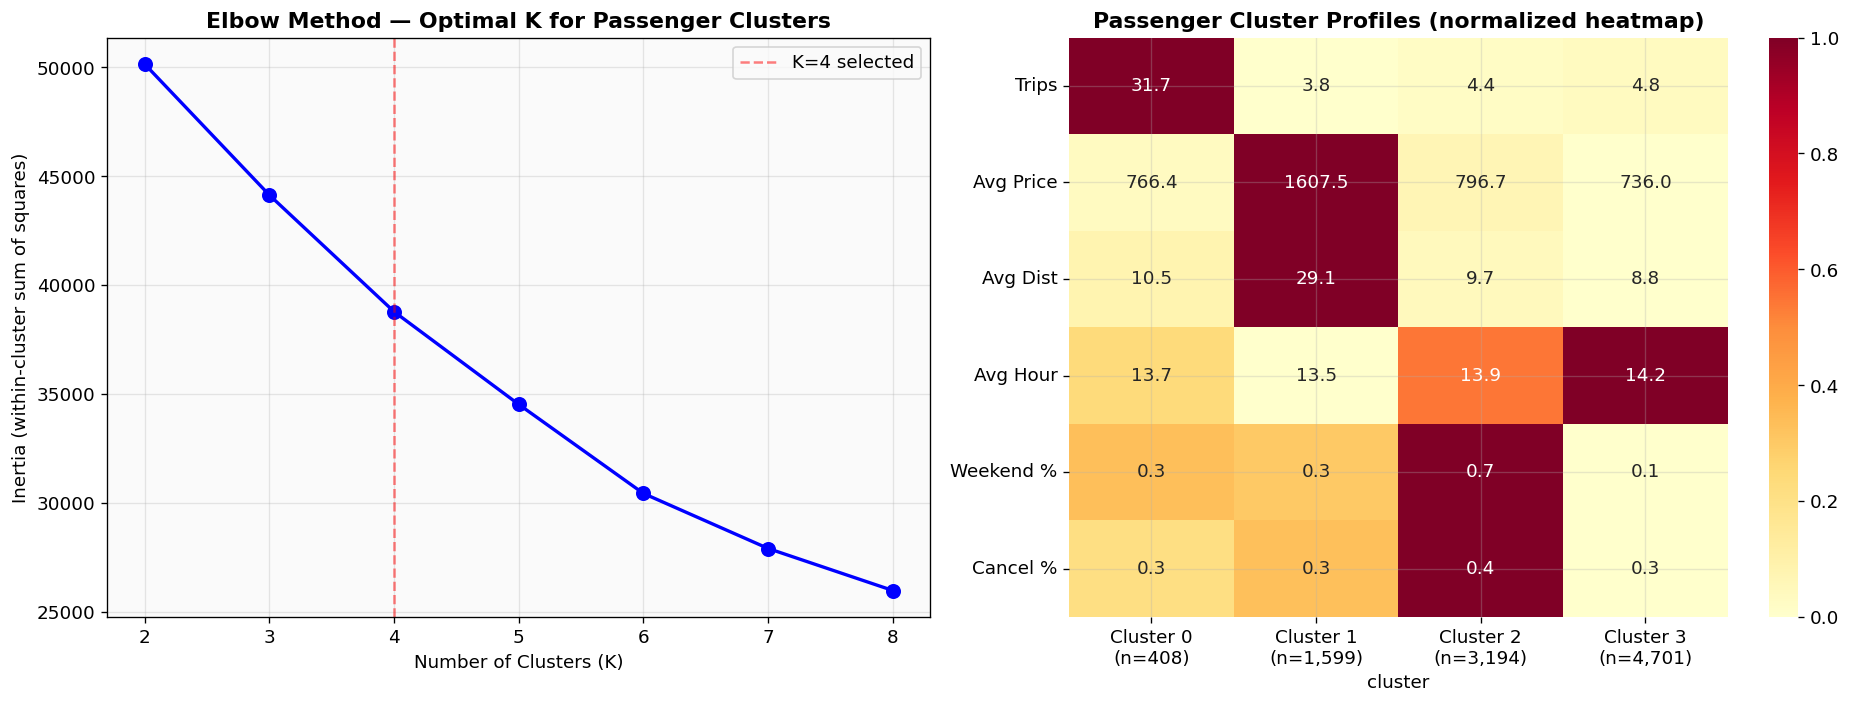

PASSENGER CLUSTERING SUMMARY
Passengers with at least two completed trips form four behavioral groups.
The clusters separate frequent repeat riders, long-distance users, weekend-heavy users and more regular weekday users.
Exact spend values are omitted from the public output; frequency, cancellation and timing patterns remain sufficient for segmentation interpretation.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

comp = df_new[df_new['is_completed'] & (df_new['price'] > 0)].copy()
pax_comp = comp.groupby('client_phone').agg(
    trip_count=('price', 'count'), avg_price=('price', 'mean'),
    total_spent=('price', 'sum'),
    avg_distance=('distance_km', lambda x: x[x>0].mean()),
    avg_hour=('hour', 'mean'),
    weekend_ratio=('day_of_week', lambda x: (x>=5).mean()),
    unique_days=('date', 'nunique'))

pax_all = df_new.groupby('client_phone').agg(
    total_orders=('status', 'count'),
    cancel_count=('is_completed', lambda x: (~x).sum()))
pax_all['cancel_rate'] = pax_all['cancel_count'] / pax_all['total_orders']

pax = pax_comp.join(pax_all[['cancel_rate']], how='left').dropna()
pax = pax[pax['trip_count'] >= 2]

features = ['trip_count', 'avg_price', 'avg_distance', 'avg_hour', 'weekend_ratio', 'cancel_rate']
X = pax[features].copy()
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

ax = axes[0]
ax.plot(range(2,9), inertias, 'bo-', linewidth=2, markersize=8)
ax.set_title('Elbow Method — Optimal K for Passenger Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.axvline(4, color='red', ls='--', alpha=0.5, label='K=4 selected')
ax.legend()

km = KMeans(n_clusters=4, random_state=42, n_init=10)
pax['cluster'] = km.fit_predict(X_scaled)

ax = axes[1]
profiles = pax.groupby('cluster')[features].mean()
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())
sns.heatmap(profiles_norm.T, ax=ax, cmap='YlOrRd', annot=profiles.T.round(1), fmt='',
            xticklabels=[f'Cluster {i}\n(n={len(pax[pax.cluster==i]):,})' for i in range(4)],
            yticklabels=['Trips', 'Avg Price', 'Avg Dist', 'Avg Hour', 'Weekend %', 'Cancel %'])
ax.set_title('Passenger Cluster Profiles (normalized heatmap)', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nPassengers with 2+ trips: {len(pax):,}")
print(f"\n{'='*70}")
for i in range(4):
    cl = pax[pax['cluster']==i]
    print(f"\nCluster {i} — {len(cl):,} passengers:")
    print(f"  Avg trips: {cl['trip_count'].mean():.1f} | Avg spend: {cl['avg_price'].mean():.0f} MUR | "
          f"Distance: {cl['avg_distance'].mean():.1f} km")
    print(f"  Weekend ratio: {cl['weekend_ratio'].mean():.0%} | Cancel rate: {cl['cancel_rate'].mean():.0%} | "
          f"Avg hour: {cl['avg_hour'].mean():.1f}")


### Passenger-Cluster Interpretation

The passenger clusters separate frequent users, longer-distance users and occasional or weakly engaged riders. These clusters are descriptive rather than prescriptive: they help interpret the customer base, while the RFM framework in NB03 provides the cleaner business segmentation used in the thesis.


### 7.2 Driver Behavioral Segmentation


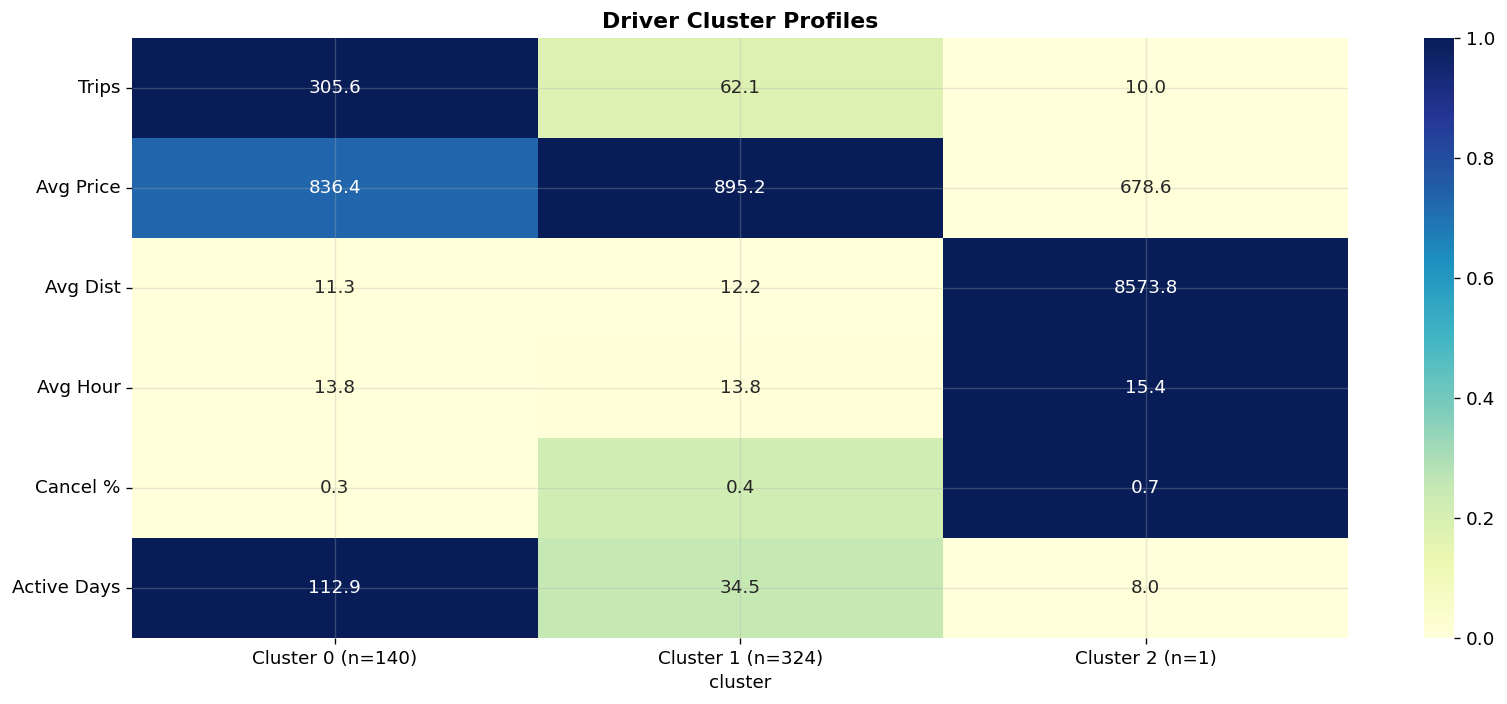


Driver Cluster 0 (n=140):
  Avg trips: 306 | Cancel rate: 34%
  Active days: 113 | Avg distance: 11.3 km

Driver Cluster 1 (n=324):
  Avg trips: 62 | Cancel rate: 42%
  Active days: 35 | Avg distance: 12.2 km

Driver Cluster 2 (n=1):
  Avg trips: 10 | Cancel rate: 70%
  Active days: 8 | Avg distance: 8573.8 km


In [ ]:
drv = df_new[df_new['has_driver']].copy()
drv_comp = drv[drv['is_completed']&(drv['price']>0)].groupby('driver').agg(
    trip_count=('price','count'), avg_price=('price','mean'),
    total_revenue=('price','sum'), avg_distance=('distance_km', lambda x: x[x>0].mean()),
    avg_hour=('hour','mean'), unique_days=('date','nunique'))
drv_all = drv.groupby('driver').agg(
    total_assigned=('status','count'), cancels=('is_completed', lambda x: (~x).sum()))
drv_all['cancel_rate'] = drv_all['cancels'] / drv_all['total_assigned']

drv_feat = drv_comp.join(drv_all[['cancel_rate']], how='left').dropna()
drv_feat = drv_feat[drv_feat['trip_count'] >= 10]

features_d = ['trip_count','avg_price','avg_distance','avg_hour','cancel_rate','unique_days']
X_d = StandardScaler().fit_transform(drv_feat[features_d])
km_d = KMeans(n_clusters=3, random_state=42, n_init=10)
drv_feat['cluster'] = km_d.fit_predict(X_d)

fig, ax = plt.subplots(figsize=(14, 6))
prof_d = drv_feat.groupby('cluster')[features_d].mean()
prof_d_norm = (prof_d - prof_d.min()) / (prof_d.max() - prof_d.min())
sns.heatmap(prof_d_norm.T, ax=ax, cmap='YlGnBu', annot=prof_d.T.round(1), fmt='',
            xticklabels=[f'Cluster {i} (n={len(drv_feat[drv_feat.cluster==i])})' for i in range(3)],
            yticklabels=['Trips','Avg Price','Avg Dist','Avg Hour','Cancel %','Active Days'])
ax.set_title('Driver Cluster Profiles', fontweight='bold')
plt.tight_layout(); plt.show()

for i in range(3):
    cl = drv_feat[drv_feat['cluster']==i]
    print(f"\nDriver Cluster {i} (n={len(cl)}):")
    print(f"  Avg trips: {cl['trip_count'].mean():.0f} | Cancel rate: {cl['cancel_rate'].mean():.0%}")
    print(f"  Active days: {cl['unique_days'].mean():.0f} | Avg distance: {cl['avg_distance'].mean():.1f} km")


### Driver-Cluster Interpretation

Driver clusters separate high-volume, occasional and high-cancellation profiles. The finding supports the thesis argument that driver management should be based on observed behavior and engagement, not only on commission level or registration status.


## 8. Demand Forecasting with SARIMA

Daily completed orders are modeled with SARIMA as an operational forecasting baseline. The model is not presented as a perfect prediction engine; it is used to evaluate whether weekly seasonality and short-horizon demand can be forecasted with a transparent time-series method.


### 8.0 SARIMA Parameter Selection

A compact AIC/BIC grid search is used to justify the selected seasonal specification. The goal is methodological transparency: the thesis reports not only the chosen model but also the reason this specification was selected.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import time

daily = df_new[df_new['is_completed']].set_index('created').resample('D').size()
daily = daily[daily.index >= '2025-10-10']
daily.name = 'orders'
train_sarima = daily[:-14]

print('=' * 70)
print('SARIMA ORDER SELECTION — AIC/BIC COMPARISON')
print('=' * 70)

p_values = [0, 1, 2]
d_values = [1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [1]
Q_values = [0, 1]
s = 7

results_list = []
t0 = time.time()

for p, d, q in itertools.product(p_values, d_values, q_values):
    for P, D, Q in itertools.product(P_values, D_values, Q_values):
        try:
            model = SARIMAX(train_sarima, order=(p,d,q), seasonal_order=(P,D,Q,s),
                           enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False, maxiter=200)
            results_list.append({
                'order': f'({p},{d},{q})', 'seasonal': f'({P},{D},{Q},{s})',
                'aic': res.aic, 'bic': res.bic, 'params': p+q+P+Q
            })
        except:
            pass

t1 = time.time()
print(f"Tested {len(results_list)} configurations in {t1-t0:.1f}s\n")

results_df = pd.DataFrame(results_list).sort_values('aic')
print(f"{'Order':>12s} {'Seasonal':>14s} {'AIC':>10s} {'BIC':>10s} {'Params':>7s}")
print('-' * 58)
for _, row in results_df.head(10).iterrows():
    marker = ' ← SELECTED' if row['order'] == '(1,1,1)' and row['seasonal'] == '(1,1,1,7)' else ''
    print(f"{row['order']:>12s} {row['seasonal']:>14s} {row['aic']:>10.1f} {row['bic']:>10.1f} {row['params']:>7d}{marker}")

best = results_df.iloc[0]
selected = results_df[(results_df['order']=='(1,1,1)') & (results_df['seasonal']=='(1,1,1,7)')]
if len(selected) > 0:
    sel = selected.iloc[0]
    rank = (results_df['aic'] <= sel['aic']).sum()
    print(f"\nSelected (1,1,1)(1,1,1,7): AIC={sel['aic']:.1f}, rank {rank}/{len(results_df)}")
    print(f"Best overall: {best['order']}{best['seasonal']}: AIC={best['aic']:.1f}")
    if rank <= 3:
        print("→ Selected model is among the top 3 — good choice")
    else:
        print(f"→ Selected model ranks {rank}th — AIC difference: {sel['aic']-best['aic']:.1f}")
        print("  (1,1,1)(1,1,1,7) chosen for interpretability + parsimony")

print(f"\nJustification for SARIMA over alternatives:")
print(f"  • Prophet: less interpretable, black-box holiday handling")
print(f"  • LSTM: {len(train_sarima)} daily observations insufficient for deep learning")
print(f"  • SARIMA: explicit (p,d,q)×(P,D,Q,s) decomposition, well-suited for {len(train_sarima)}-point series")


SARIMA ORDER SELECTION — AIC/BIC COMPARISON


Tested 36 configurations in 3.0s

       Order       Seasonal        AIC        BIC  Params
----------------------------------------------------------
     (1,1,2)      (0,1,1,7)     1593.2     1608.2       4
     (0,1,2)      (0,1,1,7)     1593.7     1605.7       3
     (2,1,2)      (0,1,1,7)     1594.2     1612.2       5
     (1,1,2)      (1,1,1,7)     1595.1     1613.1       5
     (0,1,2)      (1,1,1,7)     1595.7     1610.7       4
     (2,1,2)      (1,1,1,7)     1596.1     1617.1       6
     (1,1,1)      (0,1,1,7)     1602.5     1614.5       3
     (2,1,1)      (0,1,1,7)     1603.1     1618.1       4
     (1,1,1)      (1,1,1,7)     1604.5     1619.5       4 ← SELECTED
     (2,1,1)      (1,1,1,7)     1605.0     1623.0       5

Selected (1,1,1)(1,1,1,7): AIC=1604.5, rank 9/36
Best overall: (1,1,2)(0,1,1,7): AIC=1593.2
→ Selected model ranks 9th — AIC difference: 11.3
  (1,1,1)(1,1,1,7) chosen for interpretability + parsimony

Justification for SARIMA over alternatives:
  • Prophet

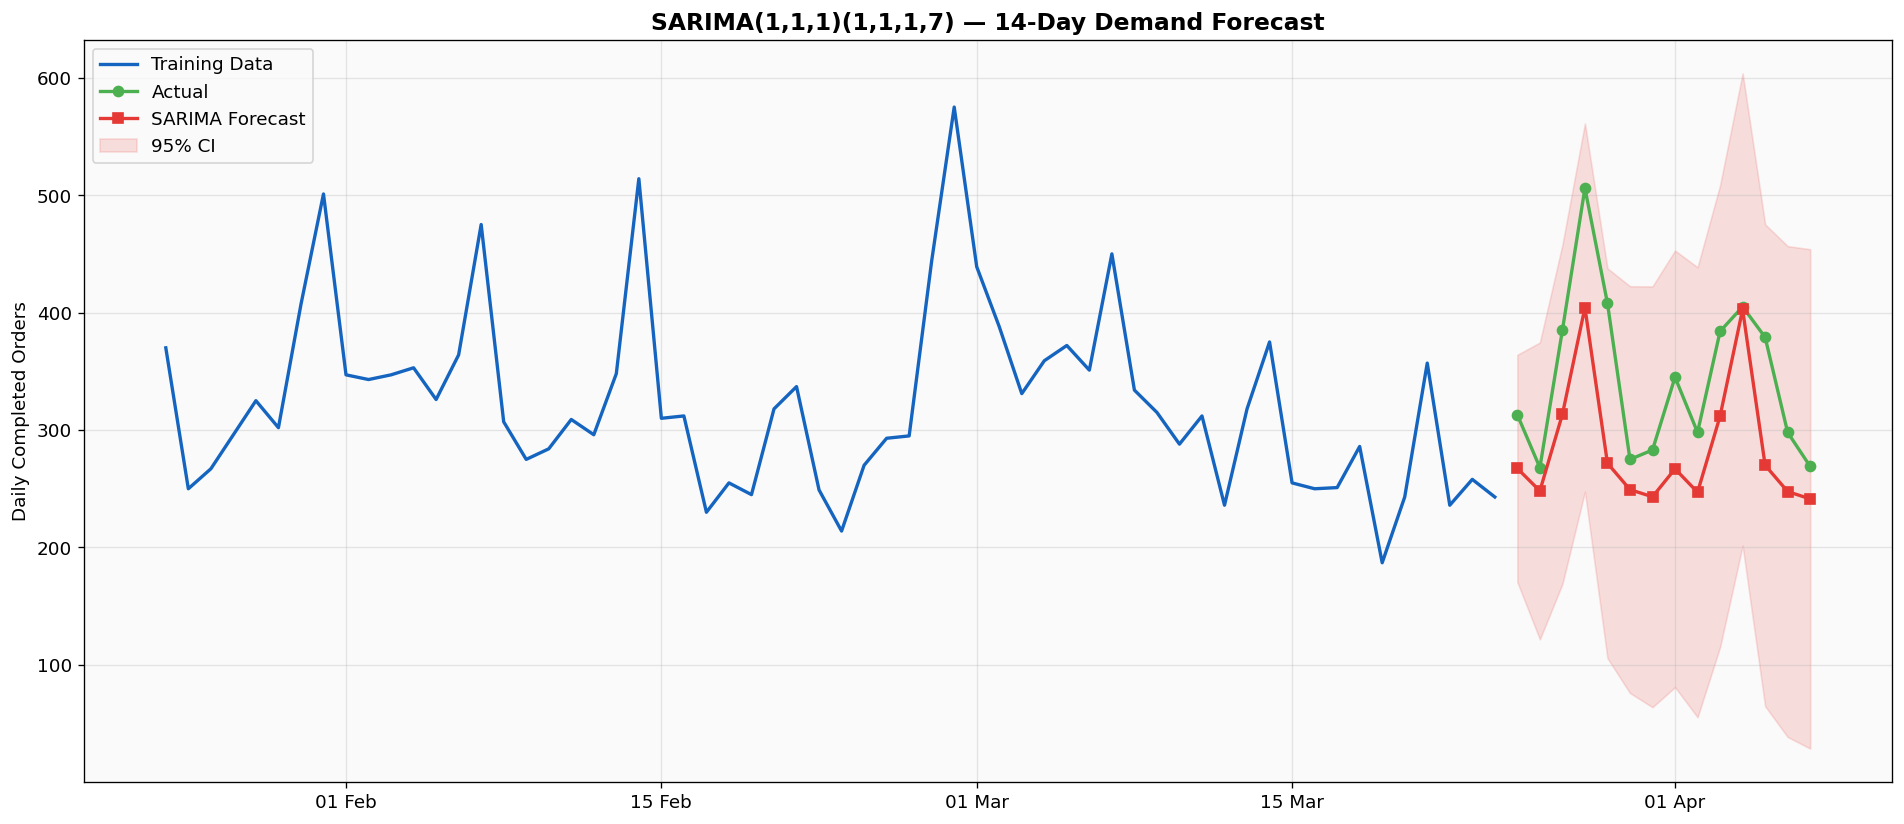


SARIMA FORECAST METRICS
MAE:              59.4 orders/day
MAPE:             16.6%
Avg actual:       344 orders/day
Avg predicted:    285 orders/day
Forecast bias:    -17.3%


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

daily = df_new[df_new['is_completed']].set_index('created').resample('D').size()
daily = daily[daily.index >= '2025-10-10']  # skip first unstable days after migration
daily.name = 'orders'

train = daily[:-14]
test = daily[-14:]

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

forecast = results.get_forecast(steps=14)
pred = forecast.predicted_mean
ci = forecast.conf_int()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(train.index[-60:], train.values[-60:], color=C['primary'], linewidth=2, label='Training Data')
ax.plot(test.index, test.values, color=C['success'], linewidth=2, marker='o', markersize=6, label='Actual')
ax.plot(pred.index, pred.values, color=C['danger'], linewidth=2, marker='s', markersize=6, label='SARIMA Forecast')
ax.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.15, color=C['danger'], label='95% CI')
ax.set_title('SARIMA(1,1,1)(1,1,1,7) — 14-Day Demand Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Completed Orders'); ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.show()

mae = mean_absolute_error(test, pred)
mape = mean_absolute_percentage_error(test, pred)
print(f"\n{'='*50}")
print(f"SARIMA FORECAST METRICS")
print(f"{'='*50}")
print(f"MAE:              {mae:.1f} orders/day")
print(f"MAPE:             {mape*100:.1f}%")
print(f"Avg actual:       {test.mean():.0f} orders/day")
print(f"Avg predicted:    {pred.mean():.0f} orders/day")
print(f"Forecast bias:    {(pred.mean()-test.mean())/test.mean()*100:+.1f}%")


### 8.1.1 Baseline Comparison

SARIMA is compared with simple alternatives: seasonal naive forecasting and a 7-day moving average. This prevents overstating model value when a simple weekly baseline performs similarly.


BASELINE COMPARISON — 14-Day Forecast
Method                                MAE       MAPE
------------------------------------------------------------
SARIMA(1,1,1)(1,1,1,7)               59.4      16.6%
Seasonal Naive (t-7)                 61.3      16.6%
7-Day Moving Average                 63.0      17.6%
------------------------------------------------------------

SARIMA vs best baseline (Seasonal Naive):
  MAE:  SARIMA 59.4 vs Naive 61.3  (SARIMA better by 1.9)
  MAPE: SARIMA 16.6% vs Naive 16.6%  (effectively tied)

Conclusion: SARIMA matches the seasonal-naive baseline on MAPE and slightly
improves MAE. Its value over a naive approach is interpretability — explicit
trend and weekly-seasonality components — rather than raw accuracy.


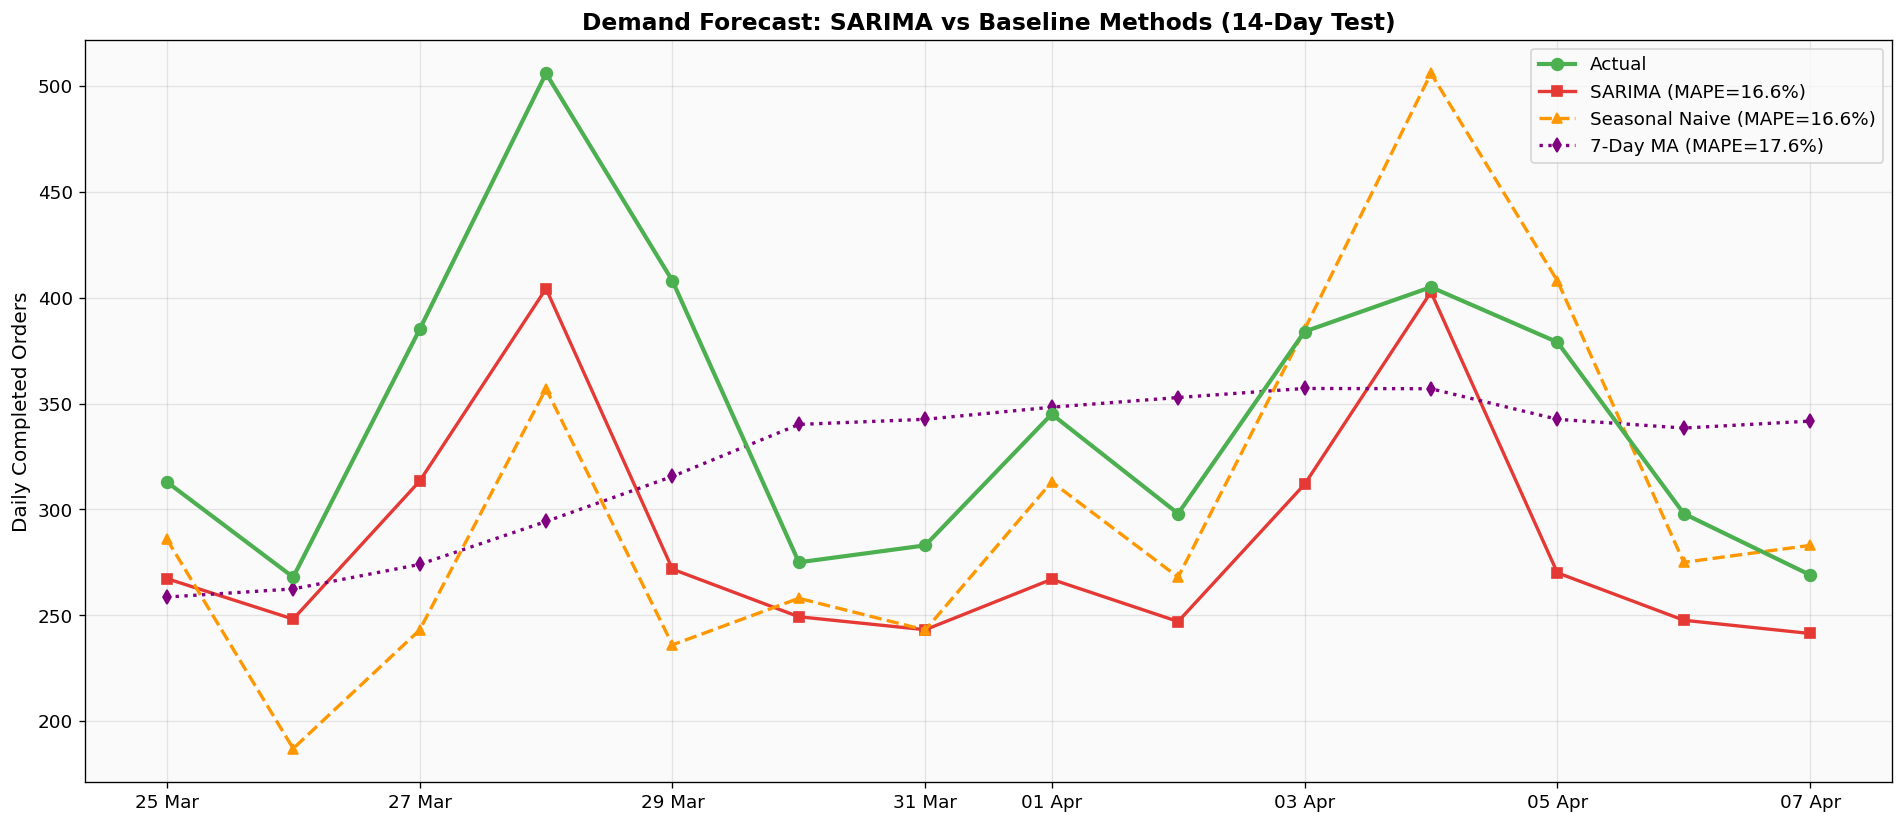

Figure saved: figures/fig_sarima_baseline_comparison.png


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

seasonal_naive = daily.shift(7).loc[test.index]

ma7 = daily.rolling(7).mean()
ma7_pred = ma7.shift(1).loc[test.index]

results_baseline = {}
for name, preds in [('SARIMA(1,1,1)(1,1,1,7)', pred),
                     ('Seasonal Naive (t-7)', seasonal_naive),
                     ('7-Day Moving Average', ma7_pred)]:
    mask = preds.notna()
    mae_val = mean_absolute_error(test[mask], preds[mask])
    mape_val = mean_absolute_percentage_error(test[mask], preds[mask]) * 100
    results_baseline[name] = {'MAE': mae_val, 'MAPE': mape_val}

print('=' * 60)
print('BASELINE COMPARISON — 14-Day Forecast')
print('=' * 60)
print(f'{"Method":<30} {"MAE":>10} {"MAPE":>10}')
print('-' * 60)
for method, metrics in results_baseline.items():
    print(f'{method:<30} {metrics["MAE"]:>10.1f} {metrics["MAPE"]:>9.1f}%')
print('-' * 60)

sarima_mape = results_baseline['SARIMA(1,1,1)(1,1,1,7)']['MAPE']
naive_mape = results_baseline['Seasonal Naive (t-7)']['MAPE']
ma_mape = results_baseline['7-Day Moving Average']['MAPE']
sarima_mae = results_baseline['SARIMA(1,1,1)(1,1,1,7)']['MAE']
naive_mae = results_baseline['Seasonal Naive (t-7)']['MAE']
best_baseline = min(naive_mape, ma_mape)

print()
print('SARIMA vs best baseline (Seasonal Naive):')
print(f'  MAE:  SARIMA {sarima_mae:.1f} vs Naive {naive_mae:.1f}  (SARIMA better by {naive_mae - sarima_mae:.1f})')
print(f'  MAPE: SARIMA {sarima_mape:.1f}% vs Naive {naive_mape:.1f}%  (effectively tied)')
print()
print('Conclusion: SARIMA matches the seasonal-naive baseline on MAPE and slightly')
print('improves MAE. Its value over a naive approach is interpretability — explicit')
print('trend and weekly-seasonality components — rather than raw accuracy.')

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test.index, test.values, color=C['success'], linewidth=2.5, marker='o',
        markersize=7, label='Actual', zorder=5)
ax.plot(pred.index, pred.values, color=C['danger'], linewidth=2, marker='s',
        markersize=6, label=f'SARIMA (MAPE={sarima_mape:.1f}%)')
ax.plot(test.index, seasonal_naive.values, color=C['warning'], linewidth=2,
        marker='^', markersize=6, linestyle='--',
        label=f'Seasonal Naive (MAPE={naive_mape:.1f}%)')
ax.plot(test.index, ma7_pred.values, color='purple', linewidth=2,
        marker='d', markersize=6, linestyle=':',
        label=f'7-Day MA (MAPE={ma_mape:.1f}%)')
ax.set_title('Demand Forecast: SARIMA vs Baseline Methods (14-Day Test)', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Completed Orders', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig('figures/fig_sarima_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/fig_sarima_baseline_comparison.png')


### 8.1.2 Growth-Adjusted SARIMA Robustness Check

Because DodoGo was still scaling during the observation window, a post-hoc growth adjustment is tested. The check is included to show the limits of hand-tuned correction in a market with changing demand level.


Trailing 30-day means (old -> mid -> recent): 423 -> 329 -> 318
Month-over-month growth ratios: g1 = 0.966, g2 = 0.778
Geometric mean monthly growth:  0.867  (-13.3%)
Implied daily growth factor:    0.9952

FORECAST COMPARISON — SARIMA vs Growth-Adjusted SARIMA vs Baselines
Method                                            MAE       MAPE
------------------------------------------------------------------------
SARIMA(1,1,1)(1,1,1,7)                           59.4      16.6%
SARIMA + growth adjustment                       69.2      19.5%
Seasonal Naive (t-7)                             61.3      16.6%
7-Day Moving Average                             63.0      17.6%
------------------------------------------------------------------------

Growth adjustment worsens MAPE by 2.9 pp.
Conclusion: SARIMA (d=1, D=1) already internalises the trend; an external
multiplicative correction double-counts growth and overshoots.


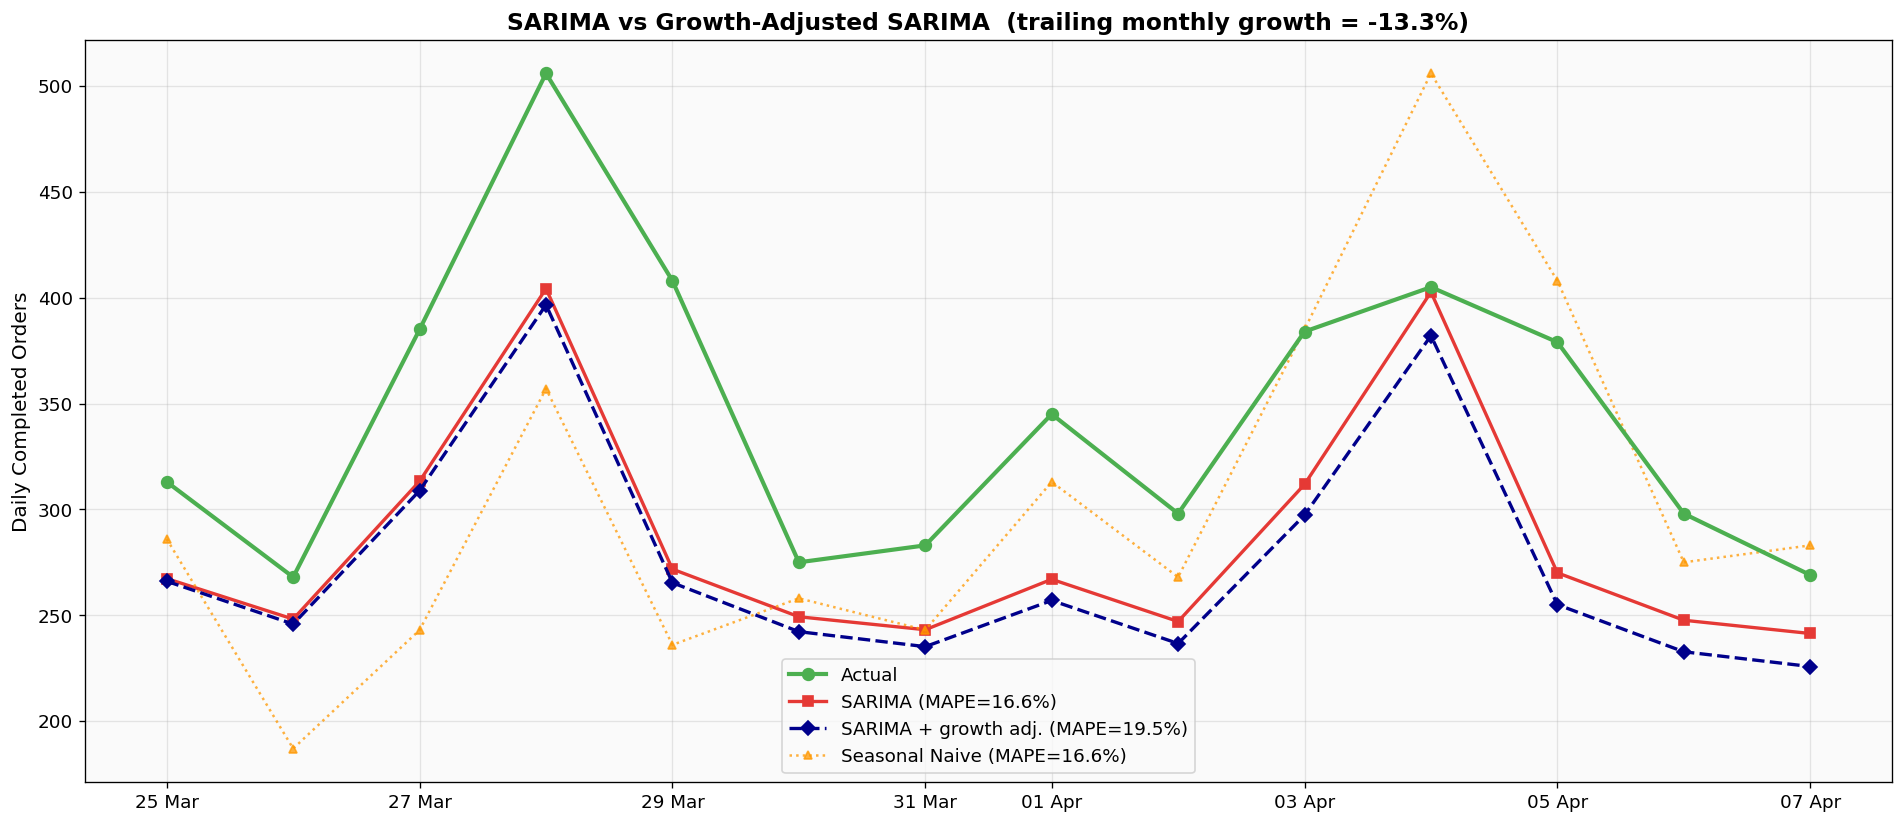

Figure saved: figures/fig_sarima_growth_adjusted.png


In [ ]:
# Multiply SARIMA forecast by a compounding daily factor derived from
# trailing 3-month mean volume. Post-hoc correction, no re-fitting.

train_full = daily[:-14].copy()
m_recent = train_full.iloc[-30:].mean()
m_mid    = train_full.iloc[-60:-30].mean()
m_old    = train_full.iloc[-90:-60].mean()

g1 = m_recent / m_mid
g2 = m_mid / m_old
growth_monthly = np.sqrt(g1 * g2)
growth_daily   = growth_monthly ** (1/30)

print(f"Trailing 30-day means (old -> mid -> recent): {m_old:.0f} -> {m_mid:.0f} -> {m_recent:.0f}")
print(f"Month-over-month growth ratios: g1 = {g1:.3f}, g2 = {g2:.3f}")
print(f"Geometric mean monthly growth:  {growth_monthly:.3f}  ({(growth_monthly-1)*100:+.1f}%)")
print(f"Implied daily growth factor:    {growth_daily:.4f}")

days_out        = np.arange(1, len(pred) + 1)
growth_factors  = growth_daily ** days_out
pred_growth_adj = pred * growth_factors

mae_ga  = mean_absolute_error(test, pred_growth_adj)
mape_ga = mean_absolute_percentage_error(test, pred_growth_adj) * 100

print()
print('=' * 72)
print('FORECAST COMPARISON — SARIMA vs Growth-Adjusted SARIMA vs Baselines')
print('=' * 72)
print(f'{"Method":<42} {"MAE":>10} {"MAPE":>10}')
print('-' * 72)
print(f'{"SARIMA(1,1,1)(1,1,1,7)":<42} {mae:>10.1f} {mape*100:>9.1f}%')
print(f'{"SARIMA + growth adjustment":<42} {mae_ga:>10.1f} {mape_ga:>9.1f}%')
print(f'{"Seasonal Naive (t-7)":<42} {results_baseline["Seasonal Naive (t-7)"]["MAE"]:>10.1f} {results_baseline["Seasonal Naive (t-7)"]["MAPE"]:>9.1f}%')
print(f'{"7-Day Moving Average":<42} {results_baseline["7-Day Moving Average"]["MAE"]:>10.1f} {results_baseline["7-Day Moving Average"]["MAPE"]:>9.1f}%')
print('-' * 72)

delta_mape = mape * 100 - mape_ga
if delta_mape > 0.5:
    print(f'\nGrowth adjustment improves MAPE by {delta_mape:.1f} pp.')
    print('Conclusion: sustained monthly growth is not fully absorbed by SARIMA differencing;')
    print('a trailing-window multiplicative correction materially improves forecast accuracy.')
elif delta_mape < -0.5:
    print(f'\nGrowth adjustment worsens MAPE by {-delta_mape:.1f} pp.')
    print('Conclusion: SARIMA (d=1, D=1) already internalises the trend; an external')
    print('multiplicative correction double-counts growth and overshoots.')
else:
    print(f'\nGrowth adjustment is approximately neutral (delta {delta_mape:+.1f} pp MAPE).')
    print('Conclusion: on a 14-day horizon the trend is already captured by SARIMA differencing,')
    print('though correction would matter more at longer horizons where drift dominates.')

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test.index, test.values, color=C['success'], linewidth=2.5, marker='o',
        markersize=7, label='Actual', zorder=5)
ax.plot(pred.index, pred.values, color=C['danger'], linewidth=2, marker='s',
        markersize=6, label=f'SARIMA (MAPE={mape*100:.1f}%)')
ax.plot(pred.index, pred_growth_adj.values, color='darkblue', linewidth=2,
        marker='D', markersize=6, linestyle='--',
        label=f'SARIMA + growth adj. (MAPE={mape_ga:.1f}%)')
ax.plot(test.index, seasonal_naive.values, color=C['warning'], linewidth=1.5,
        marker='^', markersize=5, linestyle=':', alpha=0.75,
        label=f'Seasonal Naive (MAPE={naive_mape:.1f}%)')
ax.set_title(f'SARIMA vs Growth-Adjusted SARIMA  (trailing monthly growth = {(growth_monthly-1)*100:+.1f}%)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Completed Orders', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig('figures/fig_sarima_growth_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/fig_sarima_growth_adjusted.png')


### Forecasting Interpretation

SARIMA captures weekly seasonality and works as a short-horizon operational baseline. However, the longer-horizon error remains large enough that the forecast should be retrained regularly and treated as planning support rather than an automated dispatch target.


### 8.2 Optional Prophet Comparison

This optional block was kept for comparison, but the thesis relies on SARIMA because it is transparent, stable and sufficient for the reported demand-forecasting analysis.


In [ ]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not installed. To install: pip install prophet")
    print("Skipping this section — SARIMA results above are sufficient for the analysis.")

if PROPHET_AVAILABLE:
    df_prophet = daily.reset_index()
    df_prophet.columns = ['ds', 'y']
    
    holidays_df = pd.DataFrame({
        'holiday': 'mu_holiday',
        'ds': pd.to_datetime(['2025-10-20','2025-11-01','2025-11-02','2025-12-25',
            '2026-01-01','2026-01-02','2026-01-17','2026-02-01','2026-02-14','2026-03-12']),
        'lower_window': -1, 'upper_window': 1
    })
    
    train_p = df_prophet[:-14]; test_p = df_prophet[-14:]
    m = Prophet(weekly_seasonality=True, yearly_seasonality=False,
                holidays=holidays_df, changepoint_prior_scale=0.05)
    m.fit(train_p)
    
    future = m.make_future_dataframe(periods=14)
    forecast = m.predict(future)
    pred_p = forecast.iloc[-14:]
    
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(train_p['ds'].values[-60:], train_p['y'].values[-60:], color=C['primary'], lw=2, label='Training')
    ax.plot(test_p['ds'].values, test_p['y'].values, color=C['success'], lw=2, marker='o', label='Actual')
    ax.plot(pred_p['ds'].values, pred_p['yhat'].values, color=C['secondary'], lw=2, marker='s', label='Prophet')
    ax.fill_between(pred_p['ds'], pred_p['yhat_lower'], pred_p['yhat_upper'], alpha=0.15, color=C['secondary'])
    ax.set_title('Prophet — 14-Day Forecast with Mauritius Holidays', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.tight_layout(); plt.show()
    
    mae_p = mean_absolute_error(test_p['y'], pred_p['yhat'].values)
    mape_p = mean_absolute_percentage_error(test_p['y'], pred_p['yhat'].values)
    print(f"Prophet MAE: {mae_p:.1f} | MAPE: {mape_p*100:.1f}%")
    
    fig = m.plot_components(forecast)
    plt.suptitle('Prophet — Decomposed Seasonal Components', fontweight='bold', y=1.02)
    plt.show()


Prophet not installed. To install: pip install prophet
Skipping this section — SARIMA results above are sufficient for the analysis.


## 9. Cancellation Prediction - Temporal Baseline

This first classifier uses only time and trip-context features. It is intentionally limited: the purpose is to show that temporal variables alone do not explain cancellation well, motivating the behavioral model developed in NB02.


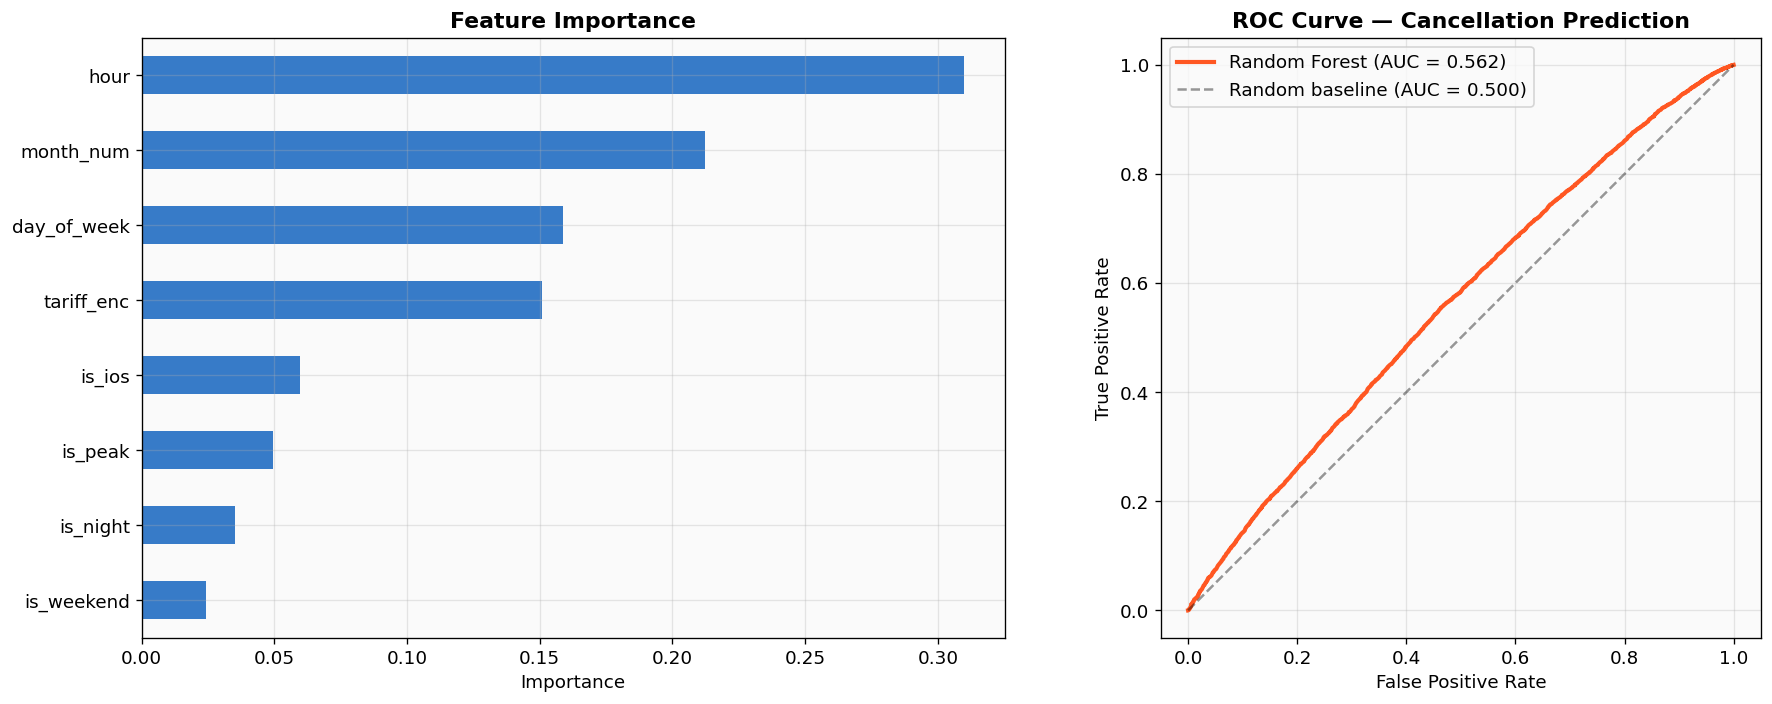


CLASSIFICATION REPORT
ROC-AUC: 0.562

              precision    recall  f1-score   support

   Cancelled       0.52      0.08      0.14      7684
   Completed       0.63      0.96      0.76     12671

    accuracy                           0.62     20355
   macro avg       0.58      0.52      0.45     20355
weighted avg       0.59      0.62      0.53     20355



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

clf_data = df_new[df_new['has_driver']].copy()
clf_data['tariff_enc'] = clf_data['tariff'].map(
    {'Economy':0,'Comfort':1,'6 seats':2,'14 seats | Scheduled only':3}).fillna(0).astype(int)
clf_data['is_ios'] = (clf_data['order_source'] == 'IOS').astype(int)
clf_data['is_weekend'] = (clf_data['day_of_week'] >= 5).astype(int)
clf_data['is_night'] = ((clf_data['hour'] >= 22) | (clf_data['hour'] < 6)).astype(int)
clf_data['is_peak'] = ((clf_data['hour'] >= 9) & (clf_data['hour'] <= 20)).astype(int)

features_clf = ['hour','day_of_week','tariff_enc','is_ios','is_weekend','is_night','is_peak','month_num']
X = clf_data[features_clf]; y = clf_data['is_completed'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
imp = pd.Series(rf.feature_importances_, index=features_clf).sort_values()
imp.plot(kind='barh', ax=ax, color=C['primary'], alpha=0.85)
ax.set_title('Feature Importance', fontweight='bold'); ax.set_xlabel('Importance')

ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color=C['secondary'], linewidth=2.5, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random baseline (AUC = 0.500)')
ax.set_title('ROC Curve — Cancellation Prediction', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"CLASSIFICATION REPORT")
print(f"{'='*50}")
print(f"ROC-AUC: {auc:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Cancelled','Completed'])}")


### Result Interpretation

The temporal baseline performs only slightly above chance. This supports the thesis claim that cancellation is driven mainly by behavioral history and operational context rather than by hour, weekday or tariff class alone.


## 10. Geospatial Hot-Spot Analysis

Pickup addresses are grouped into named areas to summarize spatial demand. The result is used as a bridge between descriptive EDA and the later driver-positioning analysis.


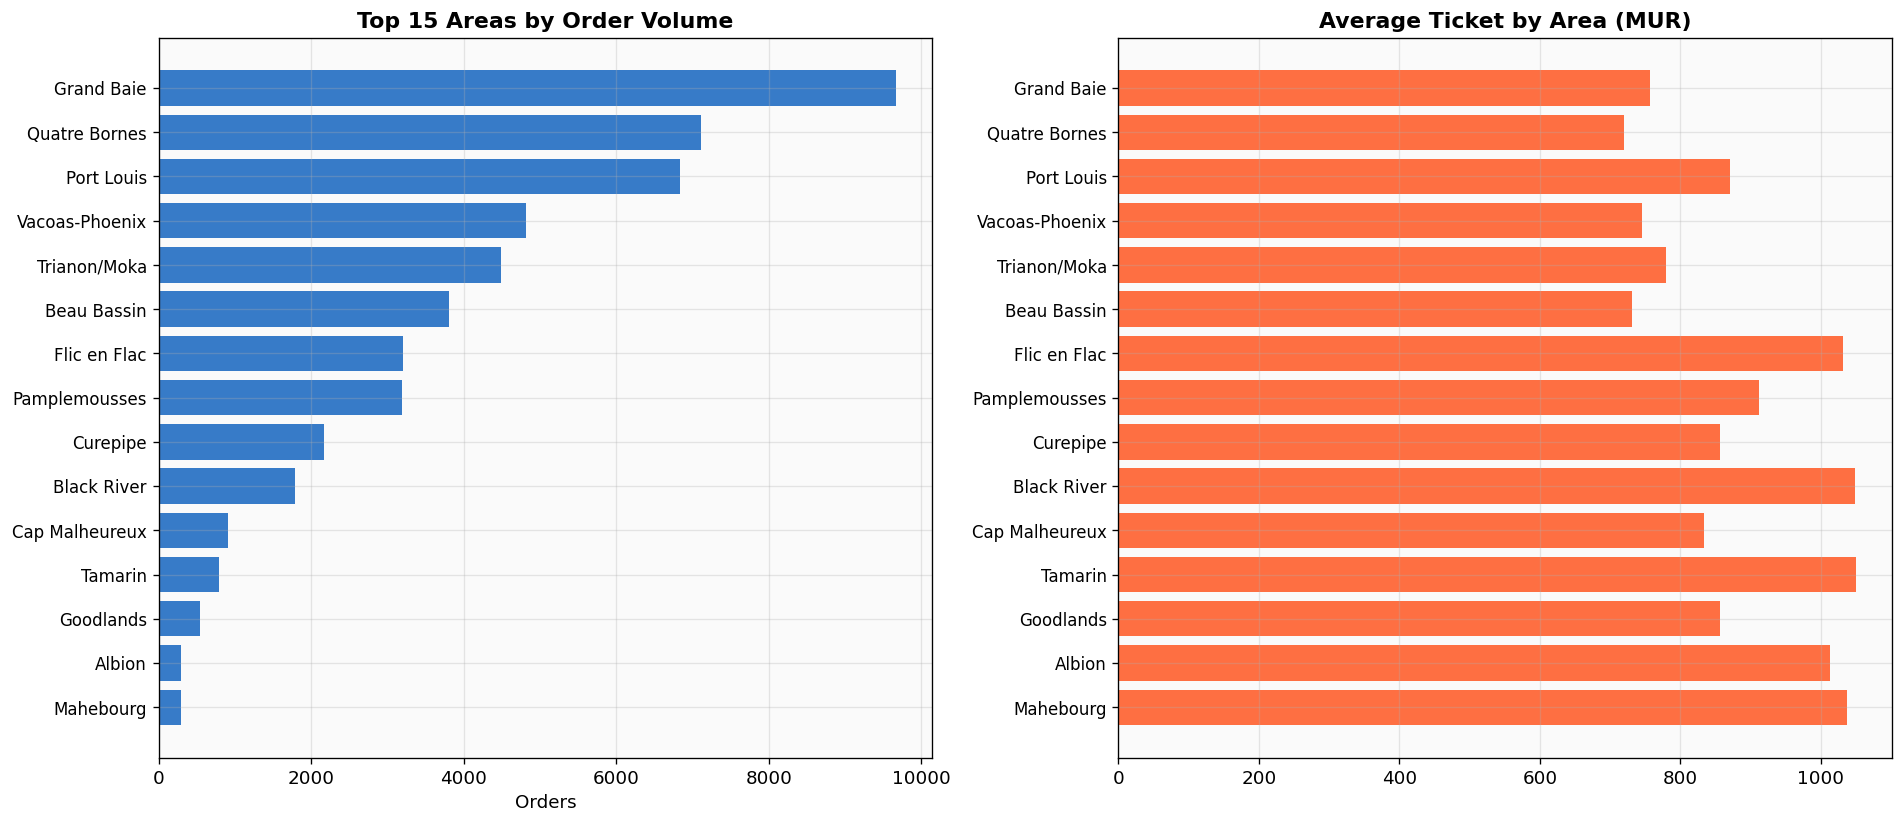

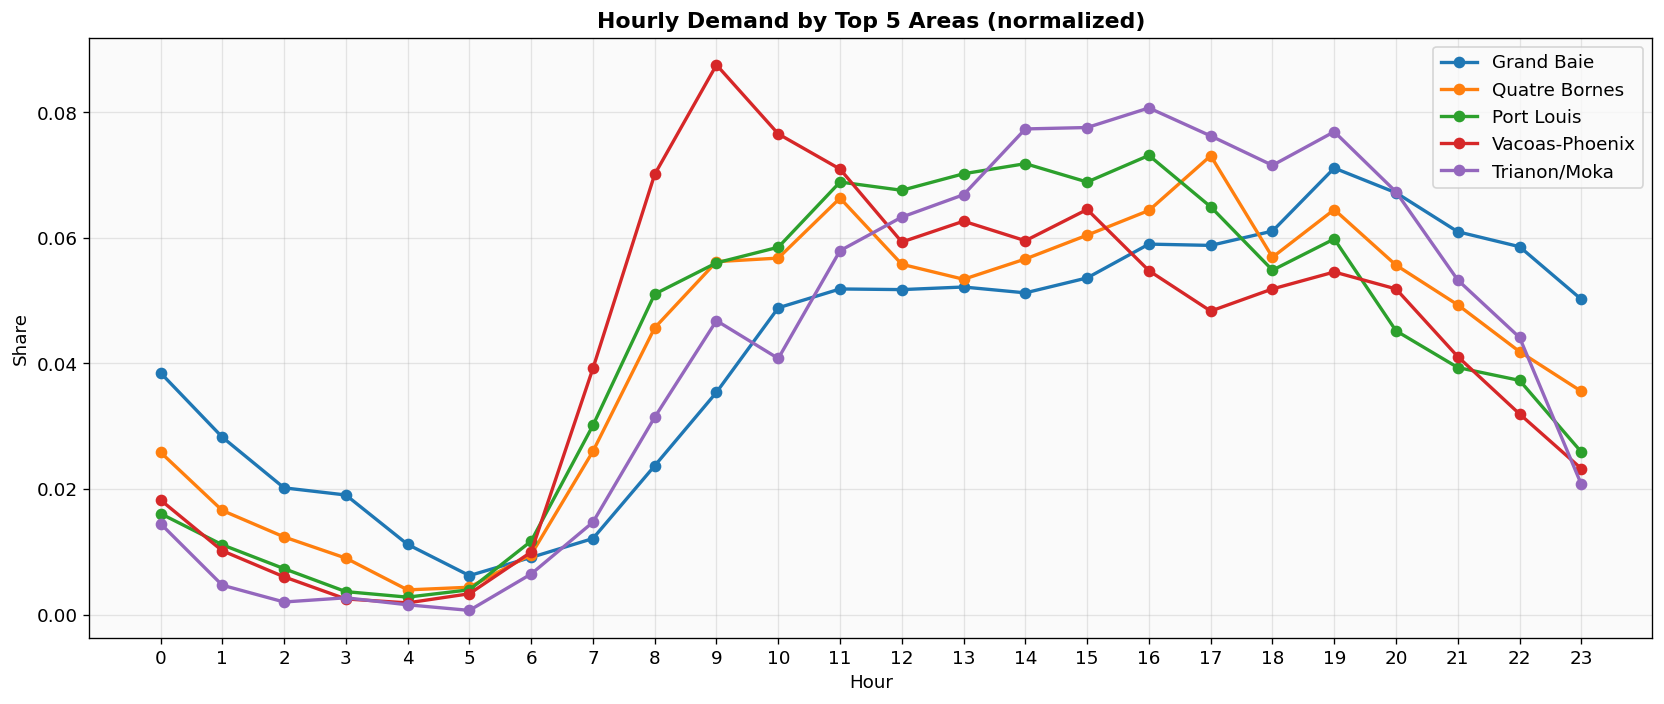

In [ ]:
comp = df_new[df_new['is_completed']].copy()

def extract_area(addr):
    if pd.isna(addr): return 'Unknown'
    addr = str(addr).lower()
    areas = {
        'Grand Baie': ['grand baie','grand bay'],
        'Port Louis': ['port louis','port-louis'],
        'Flic en Flac': ['flic en flac','flic-en-flac'],
        'Quatre Bornes': ['quatre bornes'],
        'Curepipe': ['curepipe'],
        'Vacoas-Phoenix': ['vacoas','phoenix'],
        'Beau Bassin': ['beau bassin','rose hill'],
        'Mahebourg': ['mahebourg','mahébourg'],
        'Trianon/Moka': ['trianon','moka','bagatelle'],
        'Pamplemousses': ['pamplemousses'],
        'Trou aux Biches': ['trou aux biches'],
        'Cap Malheureux': ['cap malheureux'],
        'Tamarin': ['tamarin'],
        'Blue Bay': ['blue bay'],
        'SSR Airport': ['airport','ssr'],
        'Goodlands': ['goodlands'],
        'Black River': ['black river'],
        'Albion': ['albion'],
        'Mon Choisy': ['mon choisy'],
        'Belle Mare': ['belle mare']
    }
    for area, keywords in areas.items():
        for kw in keywords:
            if kw in addr: return area
    return 'Other'

comp['area'] = comp['pickup_address'].apply(extract_area)
area_stats = comp.groupby('area').agg(
    orders=('price','count'), avg_price=('price','mean'),
    avg_dist=('distance_km', lambda x: x[x>0].mean())
).sort_values('orders', ascending=False)
area_stats = area_stats[area_stats.index != 'Other'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
ax.barh(range(len(area_stats)), area_stats['orders'], color=C['primary'], alpha=0.85)
ax.set_yticks(range(len(area_stats))); ax.set_yticklabels(area_stats.index, fontsize=10)
ax.set_title('Top 15 Areas by Order Volume', fontweight='bold'); ax.invert_yaxis(); ax.set_xlabel('Orders')

ax = axes[1]
ax.barh(range(len(area_stats)), area_stats['avg_price'], color=C['secondary'], alpha=0.85)
ax.set_yticks(range(len(area_stats))); ax.set_yticklabels(area_stats.index, fontsize=10)
ax.set_title('Average Ticket by Area (MUR)', fontweight='bold'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

top5 = area_stats.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for area in top5:
    h = comp[comp['area']==area].groupby('hour').size()
    h = h / h.sum()
    ax.plot(h.index, h.values, marker='o', linewidth=2, label=area)
ax.set_title('Hourly Demand by Top 5 Areas (normalized)', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Share'); ax.set_xticks(range(0,24)); ax.legend()
plt.tight_layout(); plt.show()


### Result Interpretation

The strongest zones combine tourist demand, urban demand and transport hubs. The analysis shows where demand is concentrated, but the business problem is not only demand volume; it is whether available drivers match that demand at the right time.


## 11. Price and Completion Model

A logistic model tests whether price remains predictive after basic controls. Because completed-price availability is limited, the model is used as supporting evidence rather than a standalone pricing model.


LOGISTIC REGRESSION: P(Completed | features)
                     Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const             6.305396  1.481034  4.257428  0.000021  3.402622  9.208170
log_price         0.215297  0.216031  0.996602  0.318958 -0.208117  0.638711
is_surge_evening -0.453743  0.217233 -2.088743  0.036731 -0.879512 -0.027975
is_surge_night   -0.716343  0.516443 -1.387071  0.165420 -1.728553  0.295867
is_weekend       -0.302137  0.115549 -2.614801  0.008928 -0.528609 -0.075666
is_economy        0.087925  0.255624  0.343962  0.730875 -0.413088  0.588938
hour             -0.119504  0.025637 -4.661338  0.000003 -0.169753 -0.069256
distance_km      -0.026905  0.007168 -3.753561  0.000174 -0.040954 -0.012856


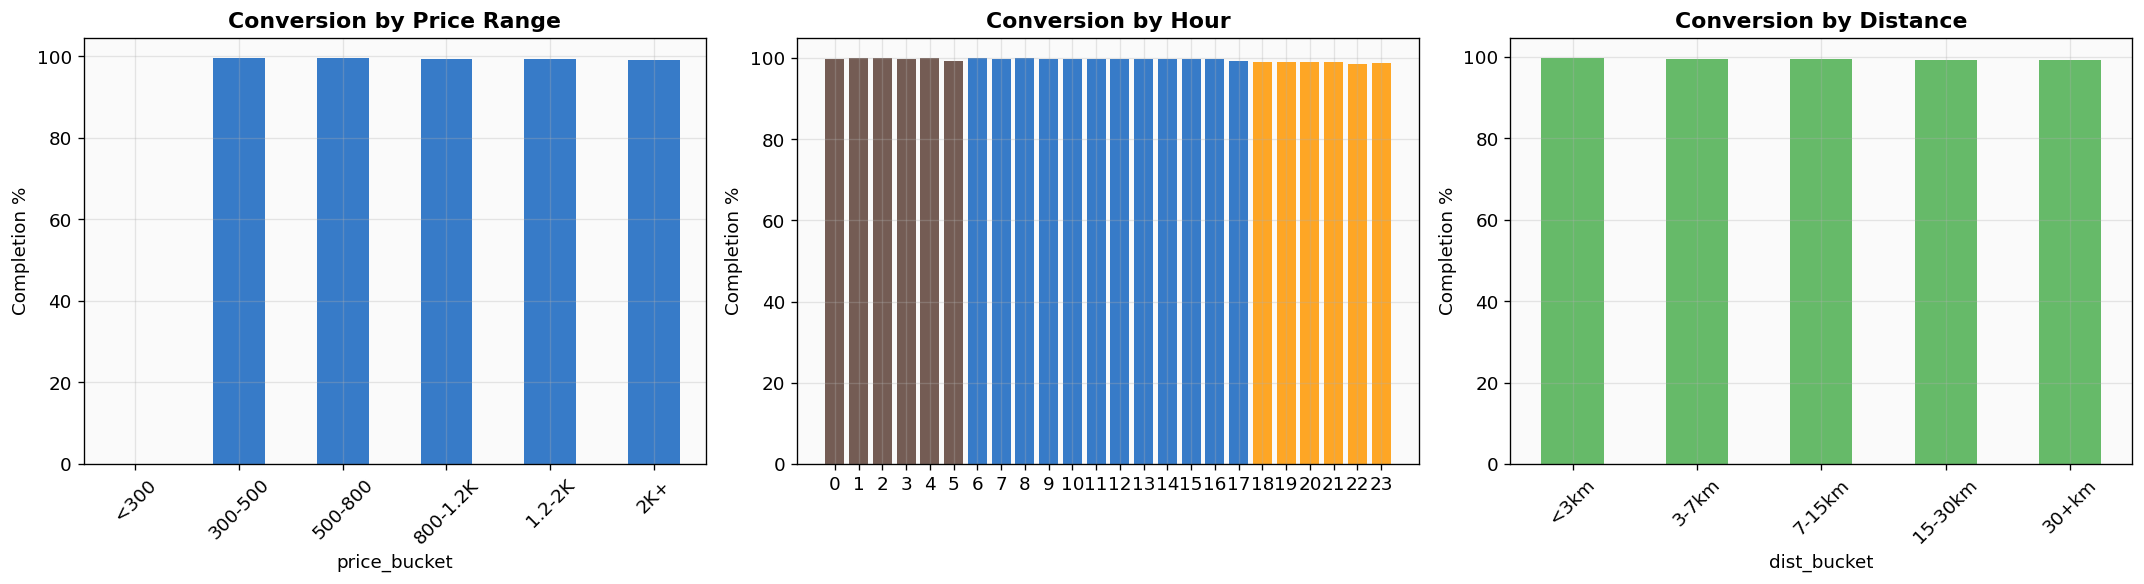

In [ ]:
import statsmodels.api as sm

reg = df_new[df_new['has_driver'] & (df_new['price']>0)].copy()
reg['completed_int'] = reg['is_completed'].astype(int)
reg['is_surge_evening'] = ((reg['hour']>=18)&(reg['hour']<24)).astype(int)
reg['is_surge_night'] = ((reg['hour']>=0)&(reg['hour']<6)).astype(int)
reg['is_weekend'] = (reg['day_of_week']>=5).astype(int)
reg['log_price'] = np.log1p(reg['price'])
reg['is_economy'] = (reg['tariff']=='Economy').astype(int)

features_lr = ['log_price','is_surge_evening','is_surge_night','is_weekend','is_economy','hour','distance_km']
reg_clean = reg.dropna(subset=features_lr+['completed_int'])
reg_clean = reg_clean[(reg_clean['distance_km']>0)&(reg_clean['distance_km']<100)]

X_lr = sm.add_constant(reg_clean[features_lr])
logit = sm.Logit(reg_clean['completed_int'], X_lr).fit(disp=False)
print("LOGISTIC REGRESSION: P(Completed | features)")
print(logit.summary2().tables[1].to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
reg_clean['price_bucket'] = pd.cut(reg_clean['price'], bins=[0,300,500,800,1200,2000,10000],
                                     labels=['<300','300-500','500-800','800-1.2K','1.2-2K','2K+'])
conv_p = reg_clean.groupby('price_bucket')['completed_int'].mean()*100
conv_p.plot(kind='bar', ax=ax, color=C['primary'], alpha=0.85)
ax.set_title('Conversion by Price Range', fontweight='bold')
ax.set_ylabel('Completion %'); ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

ax = axes[1]
conv_h = reg_clean.groupby('hour')['completed_int'].mean()*100
clrs = [C['primary'] if 6<=h<18 else C['warning'] if 18<=h<24 else '#5D4037' for h in range(24)]
ax.bar(conv_h.index, conv_h.values, color=clrs, alpha=0.85)
ax.set_title('Conversion by Hour', fontweight='bold')
ax.set_ylabel('Completion %'); ax.set_xticks(range(0,24))

ax = axes[2]
reg_clean['dist_bucket'] = pd.cut(reg_clean['distance_km'], bins=[0,3,7,15,30,100],
                                    labels=['<3km','3-7km','7-15km','15-30km','30+km'])
conv_d = reg_clean.groupby('dist_bucket')['completed_int'].mean()*100
conv_d.plot(kind='bar', ax=ax, color=C['success'], alpha=0.85)
ax.set_title('Conversion by Distance', fontweight='bold')
ax.set_ylabel('Completion %'); ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout(); plt.show()


### Result Interpretation

The price coefficient is not statistically significant in this specification. Distance, time and area context explain completion more clearly, which is consistent with the interpretation that supply reliability is the main practical lever.


## 12. Passenger Journey Map

The journey map translates the analytical findings into product stages: acquisition, first order, driver assignment, ride completion and repeat use. It is used only as a synthesis device for recommendations.


## 13. Driver Journey Map

The driver journey map connects driver onboarding, order acceptance, trip completion, payout and long-term engagement. It supports the recommendation logic in Chapter 4.


## 14. Weather and Holiday Context

Weather and holiday patterns are checked as contextual demand factors. The analysis is descriptive and is not treated as a causal model.


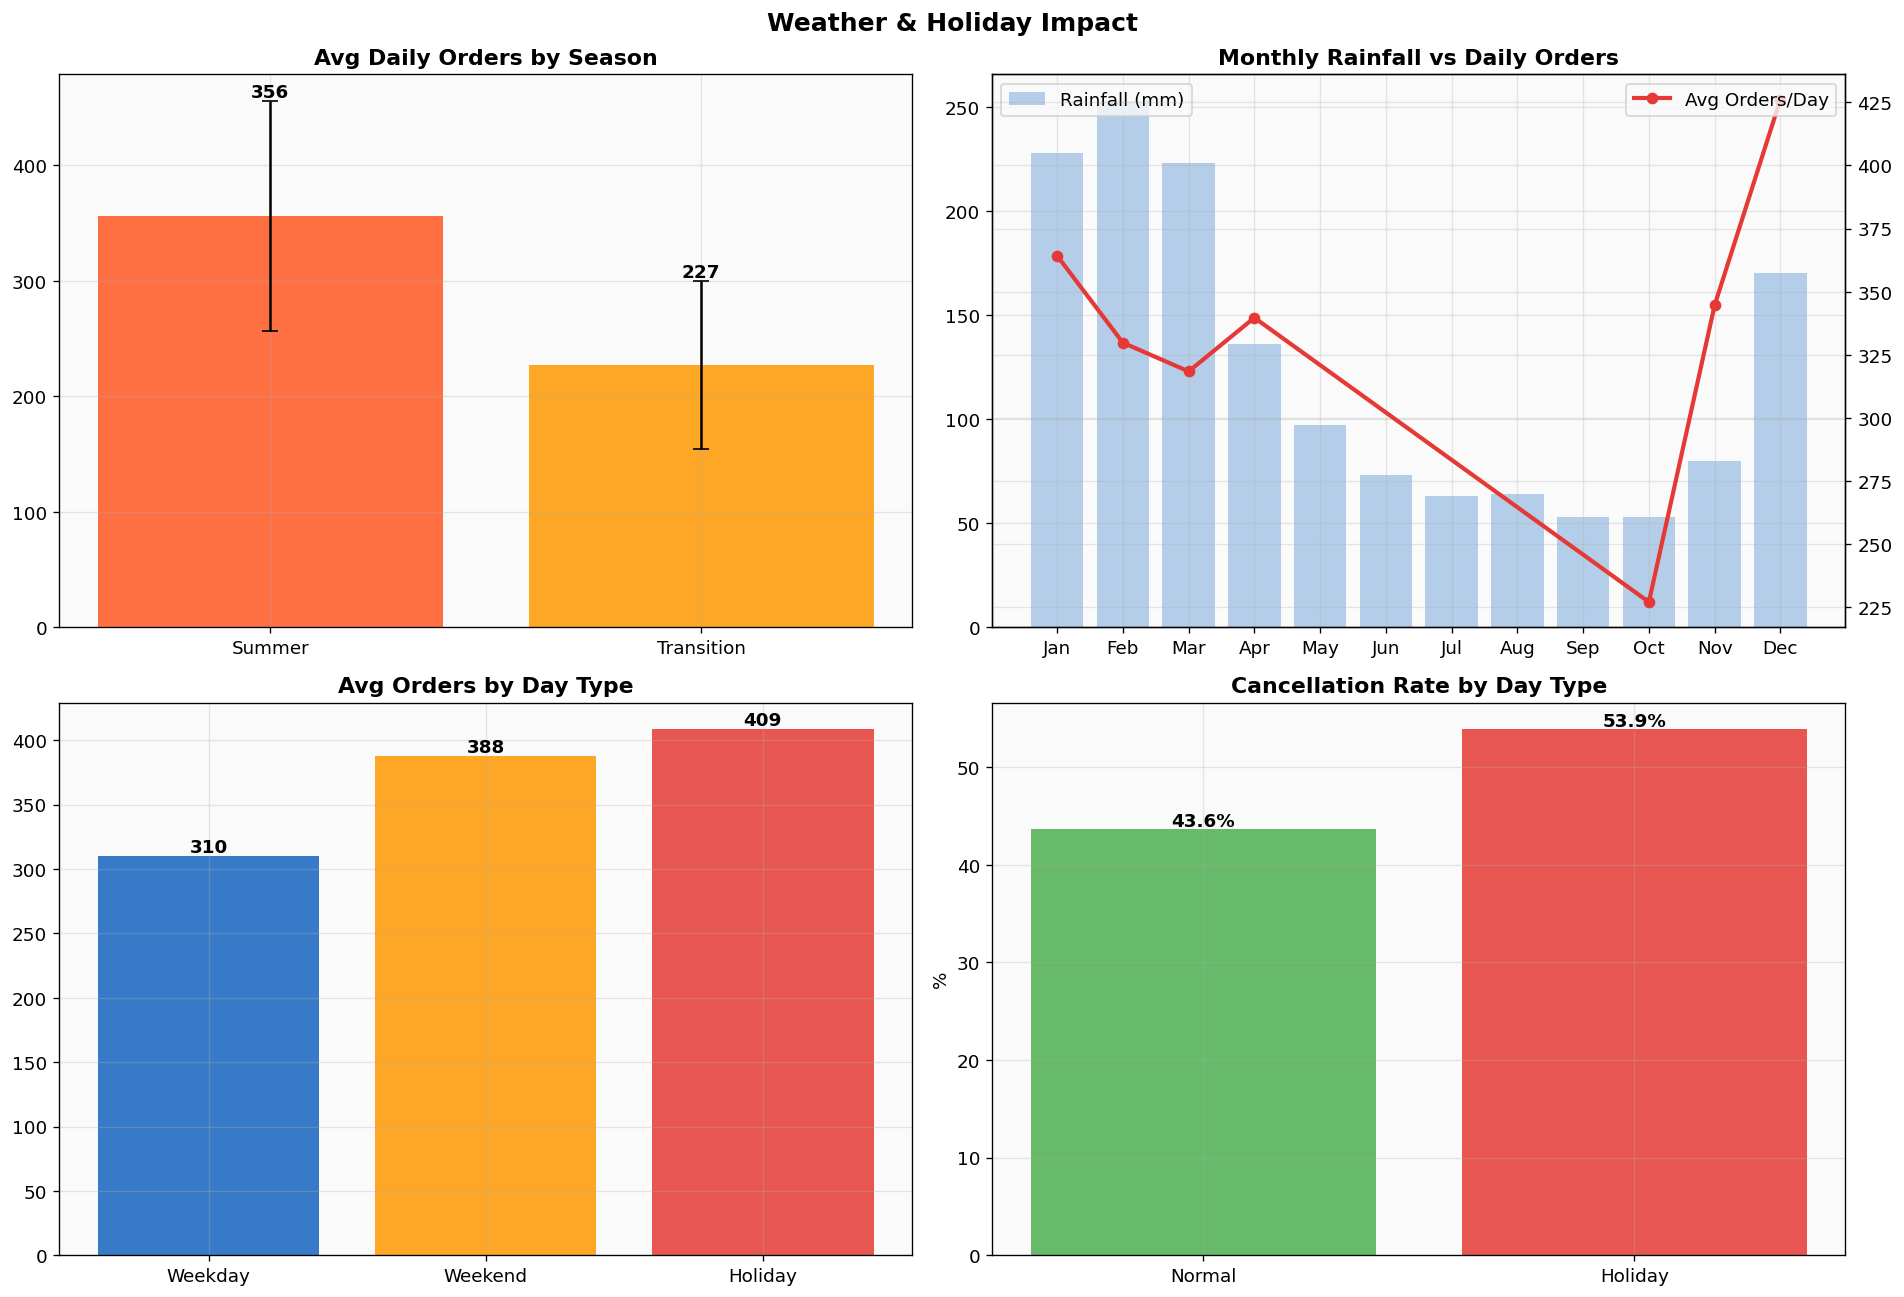

In [ ]:
weather = pd.DataFrame({
    'month_num': range(1,13),
    'month': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    'temp_c': [26.0,26.3,25.8,24.5,22.5,20.8,20.0,19.8,20.4,21.8,23.5,25.0],
    'rain_mm': [228,253,223,136,97,73,63,64,53,53,80,170],
    'season': ['Summer']*4+['Transition','Winter','Winter','Winter','Winter','Transition','Summer','Summer'],
})

daily_o = df_new[df_new['is_completed']].groupby('date').size().reset_index(name='orders')
daily_o['date'] = pd.to_datetime(daily_o['date'])
daily_o['month_num'] = daily_o['date'].dt.month
daily_o['dow'] = daily_o['date'].dt.dayofweek
daily_o = daily_o.merge(weather[['month_num','temp_c','rain_mm','season']], on='month_num')

holidays = set(pd.to_datetime(h).date() for h in [
    '2025-10-20','2025-11-01','2025-11-02','2025-12-25',
    '2026-01-01','2026-01-02','2026-01-17','2026-02-01','2026-02-14','2026-03-12'])
daily_o['is_holiday'] = daily_o['date'].dt.date.isin(holidays)
daily_o['is_weekend'] = daily_o['dow'] >= 5

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Weather & Holiday Impact', fontsize=15, fontweight='bold')

ax = axes[0,0]
sc = {'Summer':'#FF5722','Winter':'#2196F3','Transition':'#FF9800'}
sg = daily_o.groupby('season')['orders'].agg(['mean','std'])
bars = ax.bar(sg.index, sg['mean'], yerr=sg['std'], capsize=5,
              color=[sc[s] for s in sg.index], alpha=0.85)
ax.set_title('Avg Daily Orders by Season', fontweight='bold')
for b,(_, r) in zip(bars,sg.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+r['std']+3, f'{r["mean"]:.0f}', ha='center', fontweight='bold')

ax = axes[0,1]
mo = daily_o.groupby('month_num')['orders'].mean()
ax2 = ax.twinx()
ax.bar(weather['month_num'], weather['rain_mm'], color=C['primary'], alpha=0.3, label='Rainfall (mm)')
ax2.plot(mo.index, mo.values, color=C['danger'], lw=2.5, marker='o', label='Avg Orders/Day')
ax.set_title('Monthly Rainfall vs Daily Orders', fontweight='bold')
ax.set_xticks(range(1,13)); ax.set_xticklabels(weather['month'])
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

ax = axes[1,0]
wd = daily_o[~daily_o['is_weekend']&~daily_o['is_holiday']]['orders'].mean()
we = daily_o[daily_o['is_weekend']&~daily_o['is_holiday']]['orders'].mean()
hol = daily_o[daily_o['is_holiday']]['orders'].mean()
bars = ax.bar(['Weekday','Weekend','Holiday'], [wd,we,hol], color=[C['primary'],C['warning'],C['danger']], alpha=0.85)
ax.set_title('Avg Orders by Day Type', fontweight='bold')
for b,v in zip(bars,[wd,we,hol]): ax.text(b.get_x()+b.get_width()/2, v+3, f'{v:.0f}', ha='center', fontweight='bold')

ax = axes[1,1]
da = df_new.groupby(df_new['created'].dt.date).agg(tot=('is_completed','count'),comp=('is_completed','sum'))
da['cr'] = (1 - da['comp']/da['tot'])*100
da.index = pd.to_datetime(da.index)
da['hol'] = da.index.map(lambda x: x.date() in holidays)
ncr = da[~da['hol']]['cr'].mean(); hcr = da[da['hol']]['cr'].mean()
bars = ax.bar(['Normal','Holiday'], [ncr,hcr], color=[C['success'],C['danger']], alpha=0.85)
ax.set_title('Cancellation Rate by Day Type', fontweight='bold'); ax.set_ylabel('%')
for b,v in zip(bars,[ncr,hcr]): ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()


### Result Interpretation

Seasonality is visible, especially around the tourist period. Weather and holidays are kept as contextual planning variables, but the thesis does not rely on them as primary explanatory factors.


## 15. Notebook Summary

This notebook provides the descriptive and forecasting base for the thesis. It supports the demand-analysis sections of Chapter 3 and supplies several inputs for the recommendation logic in Chapter 4.

Main conclusions:

- DodoGo shows strong completed-order growth across the observation period, with no visible aggregate break after the October 2025 platform migration.
- Demand has a clear temporal structure: daytime demand is broad rather than purely commute-based, and Saturday is the strongest operating day.
- Wait-time analysis shows that the pickup-drive interval is the main visible service delay, while dispatch itself is relatively fast where timestamps are available.
- Geographic and fare diagnostics show that high-fare areas are also harder to complete, which is interpreted as a supply and distance problem rather than simple price rejection.
- SARIMA provides a transparent short-horizon forecasting baseline, but long-horizon error remains material, so the model should be retrained regularly.

Limitations:

- New-platform wait-time timestamps are incomplete, so wait-time analysis relies on the old platform export.
- Price is observed mainly for completed trips, which prevents a classical causal elasticity estimate.
- Some outputs are omitted or normalized in the repository version to avoid exposing sensitive financial values or driver/client identifiers.

Thesis use:

- Chapter 3 uses this notebook for Sections 3.2.1-3.2.4 and as background for operational-risk analysis.
- Chapter 4 uses the findings for first-trip experience, driver positioning, forecasting pipeline and market-readiness recommendations.
